In [1]:
from typing import Any, Dict

import hydra
import numpy as np
import omegaconf
import torch
import pytorch_lightning as pl
import torch.nn as nn
from torch.nn import functional as F
from torch_scatter import scatter
from tqdm import tqdm

from cdvae.common.utils import PROJECT_ROOT
from cdvae.common.data_utils import (
    EPSILON, cart_to_frac_coords, mard, lengths_angles_to_volume,
    frac_to_cart_coords, min_distance_sqr_pbc)
from cdvae.pl_modules.embeddings import MAX_ATOMIC_NUM
from cdvae.pl_modules.embeddings import KHOT_EMBEDDINGS

In [33]:
import time
import argparse
import torch

from tqdm import tqdm
from torch.optim import Adam
from pathlib import Path
from types import SimpleNamespace
#from torch_geometric.data import Batch
#from torch_geometric.data.separate import separate

#import a library that allows you to reload a module
from importlib import reload

from scripts.eval_utils import load_model

all_frac_coords_stack = []
all_atom_types_stack = []
frac_coords = []
num_atoms = []
atom_types = []
lengths = []
angles = []
input_data_list = []

#my code 
list_of_idxs = []
list_of_batchs = []

In [34]:
import importlib 
import eval_utils
importlib.reload(eval_utils)
model_path = Path("/home/gridsan/tmackey/hydra/singlerun/2024-01-11/augcag/")
model, test_loader, cfg = load_model(model_path, True, test_set_override = "mp_20")

loader = test_loader

/home/gridsan/tmackey/.conda/envs/cdvae/lib/python3.8/site-packages/hydra/experimental/compose.py:16: UserWarning: hydra.experimental.compose() is no longer experimental. Use hydra.compose()
  warnings.warn(


overriding data with  mp_20
the noise_sd is: 0.01
the noise_sd is: 0.01
constraints are max_num_atoms = 20 and source = any
using existing csv file  /home/gridsan/tmackey/cdvae/data/mp_20/test_20_any.csv
using existing graph file  /home/gridsan/tmackey/cdvae/data/mp_20/test_20_any.pt
no filter
using 9047 rows given a train_fraction of 1
[Errno 2] No such file or directory: '/home/gridsan/tmackey/cdvae/data/mp_20/test_xrd_peak_intensities_dict.pt'
time taken: 4.957018852233887
CrystDataModule(self.datasets={'train': {'_target_': 'cdvae.pl_data.dataset.CrystDataset', 'name': 'Formation energy train', 'path': '/home/gridsan/tmackey/cdvae/data/mp_20/train.csv', 'prop': 'formation_energy_per_atom', 'niggli': True, 'primitive': False, 'graph_method': 'crystalnn', 'lattice_scale_method': 'scale_length', 'preprocess_workers': 30, 'train_fraction': 1}, 'val': [{'_target_': 'cdvae.pl_data.dataset.CrystDataset', 'name': 'Formation energy val', 'path': '/home/gridsan/tmackey/cdvae/data/mp_20/val.c

/home/gridsan/tmackey/.conda/envs/cdvae/lib/python3.8/site-packages/torch_geometric/deprecation.py:13: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


In [35]:
list_of_idxs = []
list_of_batchs = []

for idx, batch in enumerate(loader):
    list_of_idxs.append(idx)
    list_of_batchs.append(batch)

idx = list_of_idxs[0]
batch = list_of_batchs[0]

def new_dataloader_batch_processor(batch): 
    batch_reserve = batch
    xrd_int = batch_reserve[1]
    xrd_loc = batch_reserve[2]
    atom_spec = batch_reserve[3]
    disc_sim_xrd = batch_reserve[4]
    pv_xrd = batch_reserve[5]
    batch = batch[0]
    return batch_reserve, xrd_int, xrd_loc, atom_spec, disc_sim_xrd, batch, pv_xrd

batch_reserve, xrd_int, xrd_loc, atom_spec, disc_sim_xrd, batch, pv_xrd = new_dataloader_batch_processor(batch)

batch = batch.cuda()

In [36]:
batch_all_frac_coords = []
batch_all_atom_types = []
batch_frac_coords, batch_num_atoms, batch_atom_types = [], [], []
batch_lengths, batch_angles = [], []

In [37]:
num_evals = 1

In [38]:
model = model.to("cuda:0")

In [39]:
from pymatgen.core.lattice import Lattice
from pymatgen.core.structure import Structure
from pymatgen.io.cif import CifWriter

xrd_int = xrd_int.cuda()
xrd_loc = xrd_loc.cuda()
atom_spec = atom_spec.cuda()
disc_sim_xrd = disc_sim_xrd.cuda()
batch = batch.cuda()
pv_xrd = pv_xrd.cuda()

#pv_xrd = torch.tensor(powder_data_list[i], dtype = torch.float32).cuda().unsqueeze(0).unsqueeze(0)
for eval_idx in range(num_evals):
    _, _, z = model.encode(None, xrd_int, xrd_loc, atom_spec, pv_xrd = pv_xrd)

    ld_kwargs = SimpleNamespace(n_step_each=100,
                                step_lr=1e-4,
                                min_sigma=0,
                                save_traj=False,
                                disable_bar=False)

    gt_atom_types = None
    gt_num_atoms = batch.num_atoms
    gt_atom_spec_torch = atom_spec

    outputs = model.langevin_dynamics(
                    z, ld_kwargs, gt_num_atoms, gt_atom_types, gt_atom_spec_torch)

    # collect sampled crystals in this batch.
    batch_frac_coords.append(outputs['frac_coords'].detach().cpu())
    batch_num_atoms.append(outputs['num_atoms'].detach().cpu())
    batch_atom_types.append(outputs['atom_types'].detach().cpu())
    batch_lengths.append(outputs['lengths'].detach().cpu())
    batch_angles.append(outputs['angles'].detach().cpu())
    if ld_kwargs.save_traj:
        batch_all_frac_coords.append(
            outputs['all_frac_coords'][::down_sample_traj_step].detach().cpu())
        batch_all_atom_types.append(
            outputs['all_atom_types'][::down_sample_traj_step].detach().cpu())

/home/gridsan/tmackey/cdvae/cdvae/common/data_utils.py:627: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(X, dtype=torch.float)
100%|██████████| 50/50 [13:28<00:00, 16.16s/it]


In [40]:
all_frac_coords_stack = []
all_atom_types_stack = []
frac_coords = []
num_atoms = []
atom_types = []
lengths = []
angles = []
input_data_list = []

In [41]:
# collect sampled crystals for this z.
frac_coords.append(torch.stack(batch_frac_coords, dim=0))
num_atoms.append(torch.stack(batch_num_atoms, dim=0))
atom_types.append(torch.stack(batch_atom_types, dim=0))
lengths.append(torch.stack(batch_lengths, dim=0))
angles.append(torch.stack(batch_angles, dim=0))
if ld_kwargs.save_traj:
    all_frac_coords_stack.append(
        torch.stack(batch_all_frac_coords, dim=0))
    all_atom_types_stack.append(
        torch.stack(batch_all_atom_types, dim=0))

In [130]:
index = 10

In [131]:
#test the diffraction loss on the first predicted compound
gt = batch[index]

In [132]:
#NOTE THE INTENSITIES WILL LOOK WRONG IF THE DOMAIN IS SET TOO WIDE WITH TOO FEW STEPS

import diffraction as dc
from math import pi
import torch
import matplotlib.pyplot as plt
import math
import numpy as np

from pymatgen.core.structure import Structure
from pymatgen.core.periodic_table import Element
from pymatgen.core.lattice import Lattice
from pymatgen.analysis.diffraction.xrd import XRDCalculator

In [133]:
batch_for_snapping = {
    'angles': gt.angles,
    'lengths': gt.lengths,
    'frac_coords': gt.frac_coords,
    'num_atoms': gt.num_atoms,
    'atom_types': gt.atom_types,
}

In [134]:
batch_for_snapping

{'angles': tensor([[78.7725, 67.0751, 67.0751]], device='cuda:0'),
 'lengths': tensor([[5.0380, 6.4668, 6.4668]], device='cuda:0'),
 'frac_coords': tensor([[0.0000e+00, 0.0000e+00, 0.0000e+00],
         [6.8877e-01, 8.1123e-01, 8.1123e-01],
         [3.1123e-01, 1.8877e-01, 1.8877e-01],
         [0.0000e+00, 3.4120e-01, 6.5880e-01],
         [0.0000e+00, 6.5880e-01, 3.4120e-01],
         [3.4587e-01, 6.5413e-01, 6.5413e-01],
         [6.5413e-01, 3.4587e-01, 3.4587e-01],
         [0.0000e+00, 0.0000e+00, 5.0000e-01],
         [5.0000e-01, 5.0000e-01, 1.0000e+00],
         [1.1931e-17, 5.0000e-01, 1.9464e-18],
         [5.0000e-01, 0.0000e+00, 5.0000e-01],
         [5.0000e-01, 7.6144e-01, 2.3856e-01],
         [5.0000e-01, 2.3856e-01, 7.6144e-01]], device='cuda:0'),
 'num_atoms': tensor([13], device='cuda:0'),
 'atom_types': tensor([39, 31, 31, 31, 31, 31, 31, 27, 27, 27, 27, 27, 27], device='cuda:0')}

The pattern will be accurate out to: 157.96318411669148


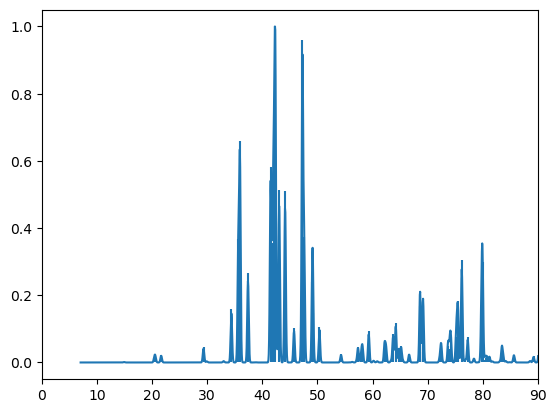

In [135]:
q_max = 8
wavelength = 1.54184
max_two_theta = 90
print("The pattern will be accurate out to:", np.arcsin((q_max * wavelength) / (4 * pi)) * 360 / pi)

#DC = dc.diffraction_calculator(q_max=10, q_step=0.1, q_width=0.1, wavelength=1.0, device='cpu')
DC = dc.diffraction_pattern(q_max= q_max, wavelength= wavelength)

mini_batch_size = 8
if batch['angles'].size()[0] % mini_batch_size != 0:
    print("set mini_batch_size to be multiplicative factor of the batch size")

pattern = DC.diffraction_calc(batch_for_snapping, indices = [0,8])

pymat_pattern = DC.pymatgen_pattern(pattern[:,0,:])[2:]
pymat_pattern[:,1] = pymat_pattern[:,1]/ torch.max(pymat_pattern[:,1])

scan, domain = DC.bin_pattern_theta(pattern, num_steps = 2560)

xrd_calculator = XRDCalculator(wavelength=wavelength)#, symprec=0.1)

structure = Structure(
    lattice=Lattice.from_parameters(
        *(batch_for_snapping['lengths'][0].tolist() + batch_for_snapping['angles'][0].tolist())),
        species=batch_for_snapping['atom_types'].tolist(), coords=batch_for_snapping['frac_coords'].tolist(), coords_are_cartesian=False)

pymatgen_pattern = xrd_calculator.get_pattern(structure)

plt.plot(domain.cpu().detach().numpy(), scan[0].cpu().detach().numpy() / torch.max(scan[0]).cpu().detach().numpy())
plt.vlines(pymatgen_pattern.x, np.zeros(len(pymatgen_pattern.x)), pymatgen_pattern.y / np.max(pymatgen_pattern.y))
plt.xlim(0,max_two_theta)
plt.show()
plt.close()

In [136]:
pred_num_atoms = batch_num_atoms[0][index]
pred_lengths = batch_lengths[0][index]
pred_angles = batch_angles[0][index] 

In [137]:
cum_sum_num_atoms = np.cumsum(batch_num_atoms[0])

In [138]:
if index == 0: 
    pred_atom_types = batch_atom_types[0][0:cum_sum_num_atoms[index]]
    pred_frac_coord = batch_frac_coords[0][0:cum_sum_num_atoms[index]]
else:
    pred_atom_types = batch_atom_types[0][cum_sum_num_atoms[index-1]:cum_sum_num_atoms[index]]
    pred_frac_coord = batch_frac_coords[0][cum_sum_num_atoms[index-1]:cum_sum_num_atoms[index]]

In [139]:
batch_to_snap = {
    'angles': torch.tensor(pred_angles.unsqueeze(0), requires_grad = True).cuda(),
    'lengths': torch.tensor(pred_lengths.unsqueeze(0), requires_grad = True).cuda(),
    'frac_coords': torch.tensor(pred_frac_coord, requires_grad = True).cuda(),
    'num_atoms': torch.tensor(pred_num_atoms.unsqueeze(0)).cuda(),
    'atom_types': torch.tensor(pred_atom_types).cuda()
}

batch_to_snap['lengths'] = batch_to_snap['lengths'].clone().detach().requires_grad_(True)
batch_to_snap['angles'] = batch_to_snap['angles'].clone().detach().requires_grad_(True)
batch_to_snap['frac_coords'] = batch_to_snap['frac_coords'].clone().detach().requires_grad_(True)
batch_to_snap

/state/partition1/slurm_tmp/24761069.0.0/ipykernel_1072965/1082058745.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'angles': torch.tensor(pred_angles.unsqueeze(0), requires_grad = True).cuda(),
/state/partition1/slurm_tmp/24761069.0.0/ipykernel_1072965/1082058745.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'lengths': torch.tensor(pred_lengths.unsqueeze(0), requires_grad = True).cuda(),
/state/partition1/slurm_tmp/24761069.0.0/ipykernel_1072965/1082058745.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'frac_coords': tor

{'angles': tensor([[79.8318, 75.4484, 74.6684]], device='cuda:0', requires_grad=True),
 'lengths': tensor([[5.4616, 6.6874, 6.9437]], device='cuda:0', requires_grad=True),
 'frac_coords': tensor([[0.0325, 0.3390, 0.1691],
         [0.5300, 0.8422, 0.1679],
         [0.0334, 0.5888, 0.4151],
         [0.5373, 0.8377, 0.6691],
         [0.5291, 0.4980, 0.5121],
         [0.1833, 0.1828, 0.5116],
         [0.2053, 0.6596, 0.9890],
         [0.8537, 0.0173, 0.3488],
         [0.8844, 0.4937, 0.8260],
         [0.5344, 0.3376, 0.1643],
         [0.0370, 0.8414, 0.6677],
         [0.0264, 0.0881, 0.9300],
         [0.5332, 0.1789, 0.8335]], device='cuda:0', requires_grad=True),
 'num_atoms': tensor([13], device='cuda:0'),
 'atom_types': tensor([27, 39, 27, 27, 31, 31, 31, 31, 31, 27, 27, 27, 31], device='cuda:0')}

In [142]:
from pymatgen.core import Structure, Lattice
from pymatgen.analysis.structure_matcher import StructureMatcher

def compare_crystals(crystal1, crystal2):
    # Function to convert dictionary to Pymatgen Structure
    def dict_to_structure(crystal):
        lattice = Lattice.from_lengths_and_angles(crystal['lengths'][0], crystal['angles'][0])
        species = crystal['atom_types'].tolist()
        coords = crystal['frac_coords'].tolist()
        return Structure(lattice, species, coords)

    # Convert dictionaries to Structures
    struct1 = dict_to_structure(crystal1)
    struct2 = dict_to_structure(crystal2)

    # Create a StructureMatcher instance
    matcher = StructureMatcher()

    # Compare the structures
    return matcher.fit(struct1, struct2)


In [144]:
from pymatgen.analysis.structure_matcher import StructureMatcher
import numpy as np

def compare_crystals(crystal1, crystal2):
    def lengths_angles_to_lattice_vectors(lengths, angles):
        a, b, c = lengths
        alpha, beta, gamma = np.radians(angles)

        # Calculate lattice vectors
        v1 = [a, 0, 0]
        v2 = [b * np.cos(gamma), b * np.sin(gamma), 0]
        v3x = c * np.cos(beta)
        v3y = c * (np.cos(alpha) - np.cos(beta) * np.cos(gamma)) / np.sin(gamma)
        v3z = np.sqrt(c**2 - v3x**2 - v3y**2)
        v3 = [v3x, v3y, v3z]

        return [v1, v2, v3]

    def dict_to_structure(crystal):
        lattice_vectors = lengths_angles_to_lattice_vectors(crystal['lengths'][0].cpu().numpy(), 
                                                            crystal['angles'][0].cpu().numpy())
        lattice = Lattice(lattice_vectors)
        species = crystal['atom_types'].cpu().numpy().tolist()
        coords = crystal['frac_coords'].cpu().numpy().tolist()
        return Structure(lattice, species, coords)

    struct1 = dict_to_structure(crystal1)
    struct2 = dict_to_structure(crystal2)

    matcher = StructureMatcher()

    return matcher.fit(struct1, struct2)

In [145]:
compare_crystals(batch_for_snapping, batch_to_snap)

RuntimeError: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.

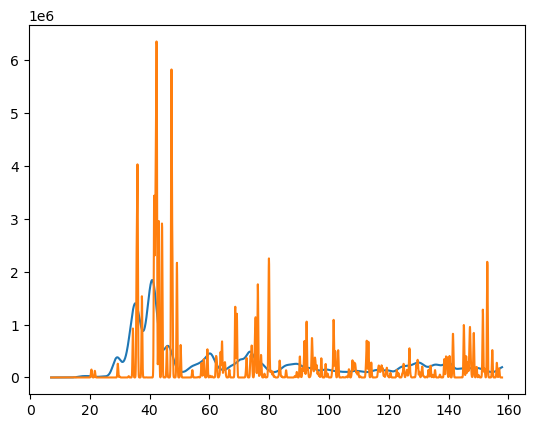

Step 1: Lengths - tensor([[5.4472, 6.6747, 6.9274]], device='cuda:0', requires_grad=True), Angles - tensor([[79.8313, 75.4484, 74.6683]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[0.0325, 0.3388, 0.1691],
        [0.5297, 0.8434, 0.1672],
        [0.0349, 0.5876, 0.4167],
        [0.5373, 0.8380, 0.6691],
        [0.5270, 0.5017, 0.5060],
        [0.1852, 0.1853, 0.5140],
        [0.2027, 0.6603, 0.9925],
        [0.8560, 0.0160, 0.3451],
        [0.8832, 0.4911, 0.8240],
        [0.5344, 0.3374, 0.1648],
        [0.0372, 0.8409, 0.6677],
        [0.0248, 0.0894, 0.9288],
        [0.5350, 0.1754, 0.8395]], device='cuda:0', requires_grad=True), Loss - -0.46142083406448364


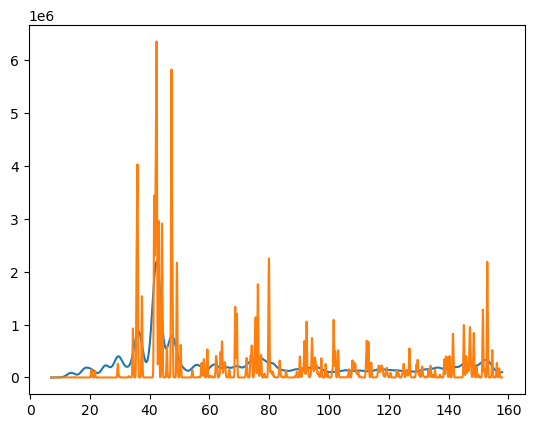

Step 201: Lengths - tensor([[5.2206, 6.6512, 6.7751]], device='cuda:0', requires_grad=True), Angles - tensor([[79.7638, 75.4549, 74.6997]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[ 0.0600,  0.3104,  0.1317],
        [ 0.4393,  0.9483,  0.2681],
        [ 0.0441,  0.5696,  0.4026],
        [ 0.5220,  0.8362,  0.6595],
        [ 0.5643,  0.5185,  0.4497],
        [ 0.3464,  0.1913,  0.5310],
        [ 0.1488,  0.6547,  1.0151],
        [ 0.9251, -0.0330,  0.3087],
        [ 0.7415,  0.5292,  0.8456],
        [ 0.5552,  0.3008,  0.1716],
        [ 0.0445,  0.8223,  0.6443],
        [ 0.0075,  0.0715,  0.9249],
        [ 0.5212,  0.1853,  0.8516]], device='cuda:0', requires_grad=True), Loss - -0.6353693008422852


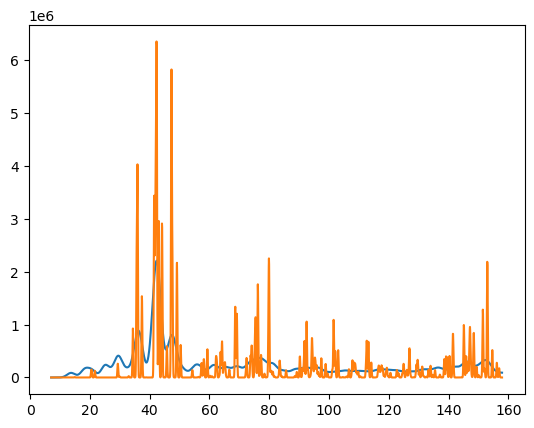

Step 401: Lengths - tensor([[5.2209, 6.6540, 6.7762]], device='cuda:0', requires_grad=True), Angles - tensor([[79.6928, 75.4488, 74.7204]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[ 0.0573,  0.3098,  0.1351],
        [ 0.4421,  0.9431,  0.2726],
        [ 0.0425,  0.5733,  0.3990],
        [ 0.5212,  0.8367,  0.6593],
        [ 0.5659,  0.5178,  0.4480],
        [ 0.3560,  0.1954,  0.5334],
        [ 0.1408,  0.6559,  1.0129],
        [ 0.9242, -0.0323,  0.3085],
        [ 0.7476,  0.5266,  0.8442],
        [ 0.5526,  0.3003,  0.1713],
        [ 0.0441,  0.8208,  0.6439],
        [ 0.0050,  0.0742,  0.9232],
        [ 0.5206,  0.1835,  0.8529]], device='cuda:0', requires_grad=True), Loss - -0.6376505494117737


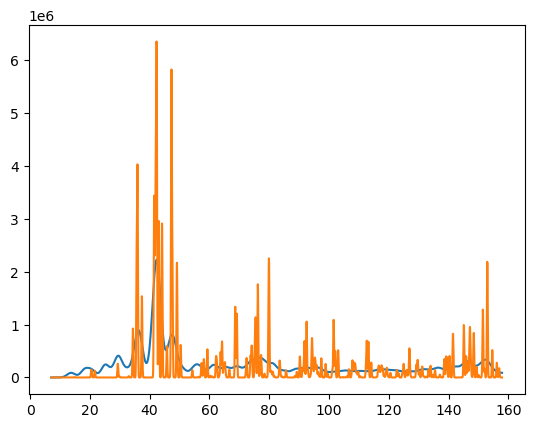

Step 601: Lengths - tensor([[5.2206, 6.6543, 6.7776]], device='cuda:0', requires_grad=True), Angles - tensor([[79.6273, 75.4434, 74.7376]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[ 0.0561,  0.3106,  0.1350],
        [ 0.4415,  0.9445,  0.2722],
        [ 0.0437,  0.5724,  0.3989],
        [ 0.5215,  0.8354,  0.6596],
        [ 0.5675,  0.5164,  0.4485],
        [ 0.3561,  0.1954,  0.5338],
        [ 0.1393,  0.6580,  1.0144],
        [ 0.9236, -0.0312,  0.3082],
        [ 0.7483,  0.5261,  0.8438],
        [ 0.5514,  0.3012,  0.1717],
        [ 0.0450,  0.8187,  0.6429],
        [ 0.0049,  0.0741,  0.9227],
        [ 0.5210,  0.1835,  0.8527]], device='cuda:0', requires_grad=True), Loss - -0.6397194862365723


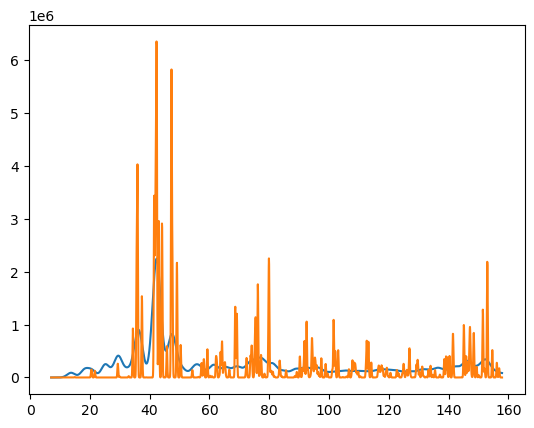

Step 801: Lengths - tensor([[5.2206, 6.6551, 6.7782]], device='cuda:0', requires_grad=True), Angles - tensor([[79.5688, 75.4388, 74.7513]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[ 0.0550,  0.3114,  0.1350],
        [ 0.4409,  0.9457,  0.2718],
        [ 0.0448,  0.5717,  0.3988],
        [ 0.5222,  0.8343,  0.6595],
        [ 0.5690,  0.5149,  0.4490],
        [ 0.3562,  0.1953,  0.5342],
        [ 0.1382,  0.6596,  1.0153],
        [ 0.9231, -0.0301,  0.3078],
        [ 0.7485,  0.5257,  0.8437],
        [ 0.5502,  0.3019,  0.1721],
        [ 0.0459,  0.8171,  0.6420],
        [ 0.0045,  0.0743,  0.9226],
        [ 0.5214,  0.1832,  0.8524]], device='cuda:0', requires_grad=True), Loss - -0.6416751742362976


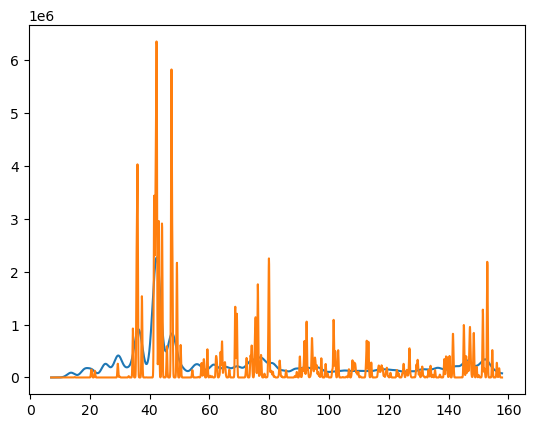

Step 1001: Lengths - tensor([[5.2208, 6.6568, 6.7780]], device='cuda:0', requires_grad=True), Angles - tensor([[79.5168, 75.4342, 74.7607]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[ 0.0539,  0.3123,  0.1351],
        [ 0.4405,  0.9466,  0.2716],
        [ 0.0455,  0.5715,  0.3987],
        [ 0.5228,  0.8335,  0.6593],
        [ 0.5701,  0.5134,  0.4497],
        [ 0.3564,  0.1955,  0.5348],
        [ 0.1373,  0.6608,  1.0159],
        [ 0.9229, -0.0292,  0.3074],
        [ 0.7487,  0.5250,  0.8437],
        [ 0.5491,  0.3024,  0.1725],
        [ 0.0467,  0.8161,  0.6412],
        [ 0.0041,  0.0749,  0.9226],
        [ 0.5219,  0.1823,  0.8520]], device='cuda:0', requires_grad=True), Loss - -0.6435289978981018


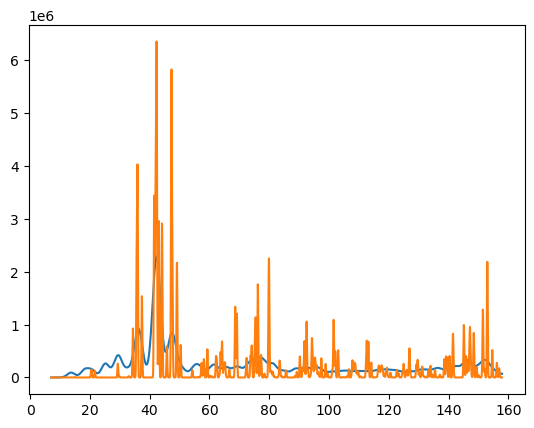

Step 1201: Lengths - tensor([[5.2210, 6.6613, 6.7768]], device='cuda:0', requires_grad=True), Angles - tensor([[79.4699, 75.4294, 74.7659]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[ 0.0533,  0.3132,  0.1348],
        [ 0.4408,  0.9471,  0.2719],
        [ 0.0455,  0.5719,  0.3985],
        [ 0.5230,  0.8331,  0.6592],
        [ 0.5711,  0.5119,  0.4503],
        [ 0.3568,  0.1967,  0.5359],
        [ 0.1354,  0.6621,  1.0162],
        [ 0.9230, -0.0287,  0.3068],
        [ 0.7494,  0.5238,  0.8435],
        [ 0.5480,  0.3023,  0.1728],
        [ 0.0473,  0.8161,  0.6403],
        [ 0.0034,  0.0761,  0.9229],
        [ 0.5230,  0.1796,  0.8513]], device='cuda:0', requires_grad=True), Loss - -0.6453124284744263


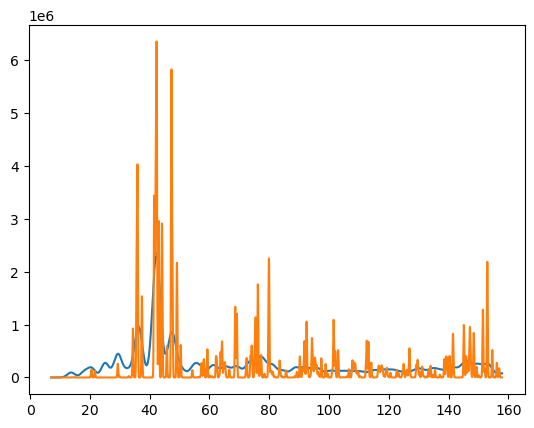

Step 1401: Lengths - tensor([[5.2223, 6.7142, 6.7616]], device='cuda:0', requires_grad=True), Angles - tensor([[79.4124, 75.4234, 74.7737]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[ 0.0601,  0.3165,  0.1264],
        [ 0.4551,  0.9403,  0.2770],
        [ 0.0355,  0.5760,  0.4014],
        [ 0.5163,  0.8393,  0.6604],
        [ 0.5618,  0.5183,  0.4518],
        [ 0.3547,  0.2032,  0.5448],
        [ 0.1187,  0.6705,  1.0173],
        [ 0.9322, -0.0421,  0.3027],
        [ 0.7535,  0.5144,  0.8405],
        [ 0.5500,  0.3002,  0.1693],
        [ 0.0438,  0.8335,  0.6387],
        [ 0.0049,  0.0747,  0.9254],
        [ 0.5334,  0.1603,  0.8486]], device='cuda:0', requires_grad=True), Loss - -0.6480435729026794


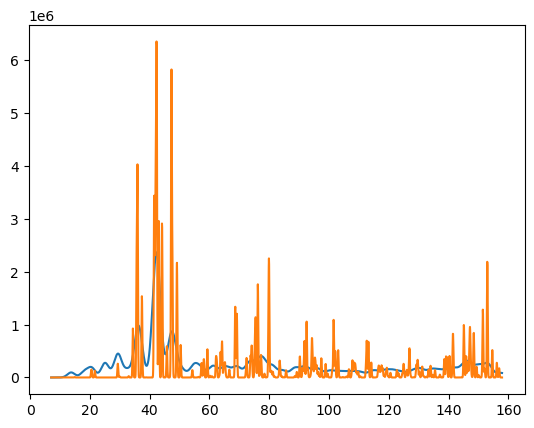

Step 1601: Lengths - tensor([[5.2248, 6.7208, 6.7548]], device='cuda:0', requires_grad=True), Angles - tensor([[79.3446, 75.4309, 74.7802]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[ 0.0719,  0.3097,  0.1247],
        [ 0.4625,  0.9374,  0.2751],
        [ 0.0203,  0.5810,  0.4105],
        [ 0.5114,  0.8433,  0.6607],
        [ 0.5416,  0.5276,  0.4617],
        [ 0.3544,  0.2074,  0.5414],
        [ 0.1138,  0.6740,  1.0164],
        [ 0.9391, -0.0495,  0.3016],
        [ 0.7540,  0.5107,  0.8383],
        [ 0.5588,  0.2968,  0.1627],
        [ 0.0338,  0.8436,  0.6457],
        [ 0.0182,  0.0676,  0.9204],
        [ 0.5401,  0.1555,  0.8452]], device='cuda:0', requires_grad=True), Loss - -0.6502984762191772


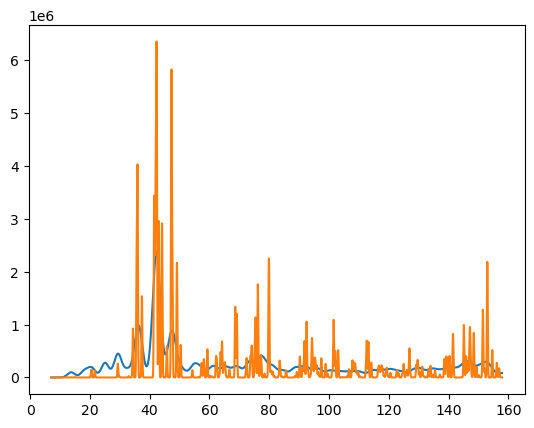

Step 1801: Lengths - tensor([[5.2259, 6.7246, 6.7458]], device='cuda:0', requires_grad=True), Angles - tensor([[79.2764, 75.4430, 74.7859]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[ 0.0774,  0.3046,  0.1265],
        [ 0.4645,  0.9373,  0.2737],
        [ 0.0143,  0.5830,  0.4132],
        [ 0.5118,  0.8441,  0.6598],
        [ 0.5294,  0.5324,  0.4705],
        [ 0.3540,  0.2098,  0.5377],
        [ 0.1128,  0.6763,  1.0148],
        [ 0.9413, -0.0511,  0.3018],
        [ 0.7533,  0.5096,  0.8378],
        [ 0.5622,  0.2967,  0.1585],
        [ 0.0316,  0.8438,  0.6489],
        [ 0.0237,  0.0661,  0.9177],
        [ 0.5435,  0.1527,  0.8433]], device='cuda:0', requires_grad=True), Loss - -0.652366578578949


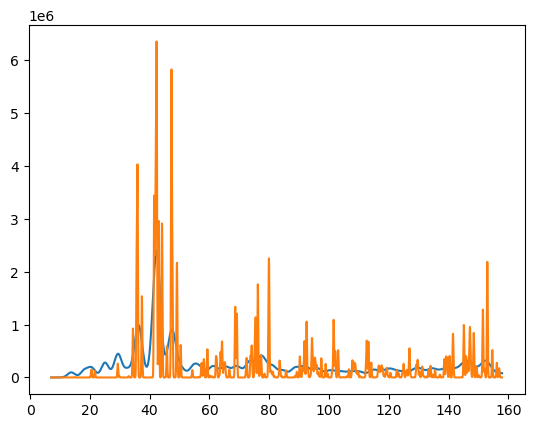

Step 2001: Lengths - tensor([[5.2267, 6.7283, 6.7372]], device='cuda:0', requires_grad=True), Angles - tensor([[79.2073, 75.4568, 74.7896]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[ 0.0779,  0.3033,  0.1280],
        [ 0.4648,  0.9374,  0.2731],
        [ 0.0112,  0.5839,  0.4137],
        [ 0.5138,  0.8437,  0.6585],
        [ 0.5225,  0.5345,  0.4782],
        [ 0.3554,  0.2106,  0.5353],
        [ 0.1130,  0.6777,  1.0129],
        [ 0.9416, -0.0507,  0.3019],
        [ 0.7539,  0.5090,  0.8383],
        [ 0.5623,  0.2982,  0.1563],
        [ 0.0321,  0.8414,  0.6502],
        [ 0.0254,  0.0661,  0.9159],
        [ 0.5459,  0.1500,  0.8418]], device='cuda:0', requires_grad=True), Loss - -0.6543928384780884


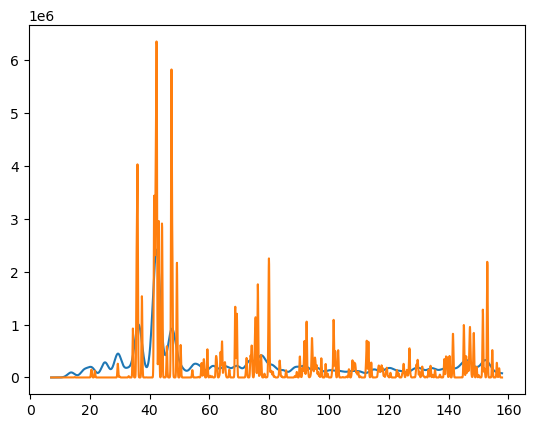

Step 2201: Lengths - tensor([[5.2273, 6.7290, 6.7352]], device='cuda:0', requires_grad=True), Angles - tensor([[79.1428, 75.4688, 74.7927]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[ 0.0764,  0.3037,  0.1297],
        [ 0.4648,  0.9378,  0.2731],
        [ 0.0098,  0.5834,  0.4136],
        [ 0.5144,  0.8431,  0.6580],
        [ 0.5204,  0.5350,  0.4801],
        [ 0.3574,  0.2107,  0.5343],
        [ 0.1138,  0.6776,  1.0117],
        [ 0.9414, -0.0503,  0.3021],
        [ 0.7548,  0.5093,  0.8393],
        [ 0.5612,  0.2994,  0.1565],
        [ 0.0330,  0.8394,  0.6501],
        [ 0.0256,  0.0665,  0.9149],
        [ 0.5469,  0.1496,  0.8410]], device='cuda:0', requires_grad=True), Loss - -0.6563084721565247


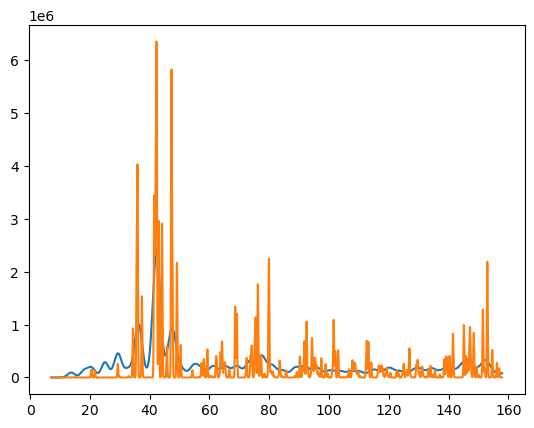

Step 2401: Lengths - tensor([[5.2278, 6.7273, 6.7364]], device='cuda:0', requires_grad=True), Angles - tensor([[79.0835, 75.4785, 74.7973]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[ 0.0745,  0.3043,  0.1324],
        [ 0.4645,  0.9381,  0.2735],
        [ 0.0108,  0.5816,  0.4130],
        [ 0.5134,  0.8425,  0.6584],
        [ 0.5235,  0.5340,  0.4769],
        [ 0.3596,  0.2103,  0.5337],
        [ 0.1145,  0.6760,  1.0111],
        [ 0.9406, -0.0503,  0.3026],
        [ 0.7549,  0.5108,  0.8402],
        [ 0.5604,  0.2998,  0.1574],
        [ 0.0334,  0.8382,  0.6496],
        [ 0.0240,  0.0675,  0.9149],
        [ 0.5458,  0.1522,  0.8407]], device='cuda:0', requires_grad=True), Loss - -0.6581358313560486


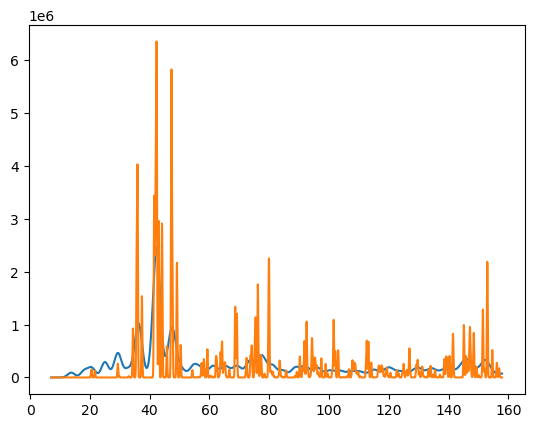

Step 2601: Lengths - tensor([[5.2289, 6.7253, 6.7379]], device='cuda:0', requires_grad=True), Angles - tensor([[79.0284, 75.4870, 74.8034]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[ 0.0726,  0.3051,  0.1356],
        [ 0.4642,  0.9385,  0.2739],
        [ 0.0130,  0.5797,  0.4120],
        [ 0.5117,  0.8418,  0.6590],
        [ 0.5298,  0.5321,  0.4717],
        [ 0.3619,  0.2096,  0.5335],
        [ 0.1146,  0.6739,  1.0107],
        [ 0.9397, -0.0502,  0.3028],
        [ 0.7546,  0.5128,  0.8412],
        [ 0.5595,  0.3002,  0.1587],
        [ 0.0339,  0.8373,  0.6489],
        [ 0.0207,  0.0692,  0.9155],
        [ 0.5438,  0.1553,  0.8410]], device='cuda:0', requires_grad=True), Loss - -0.6599022150039673


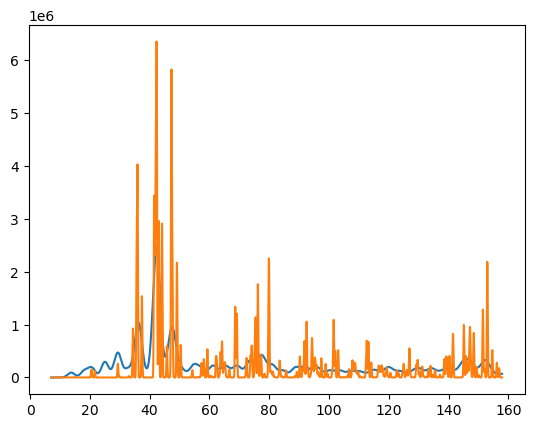

Step 2801: Lengths - tensor([[5.2308, 6.7239, 6.7390]], device='cuda:0', requires_grad=True), Angles - tensor([[78.9772, 75.4963, 74.8095]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[ 0.0708,  0.3060,  0.1386],
        [ 0.4639,  0.9393,  0.2743],
        [ 0.0160,  0.5780,  0.4109],
        [ 0.5102,  0.8407,  0.6595],
        [ 0.5381,  0.5296,  0.4665],
        [ 0.3639,  0.2090,  0.5336],
        [ 0.1136,  0.6718,  1.0105],
        [ 0.9384, -0.0499,  0.3027],
        [ 0.7538,  0.5145,  0.8420],
        [ 0.5582,  0.3009,  0.1599],
        [ 0.0353,  0.8364,  0.6479],
        [ 0.0161,  0.0711,  0.9165],
        [ 0.5416,  0.1576,  0.8415]], device='cuda:0', requires_grad=True), Loss - -0.6616125702857971


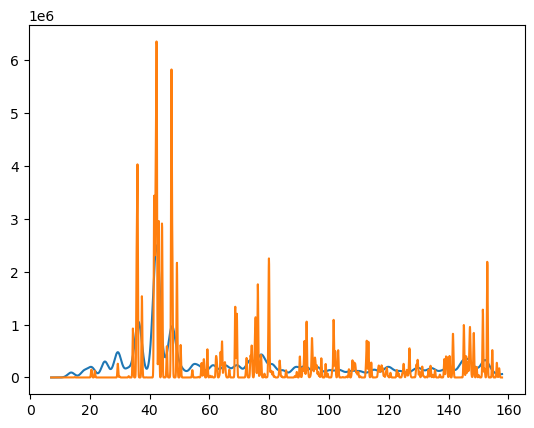

Step 3001: Lengths - tensor([[5.2336, 6.7231, 6.7393]], device='cuda:0', requires_grad=True), Angles - tensor([[78.9299, 75.5079, 74.8149]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[ 0.0697,  0.3067,  0.1412],
        [ 0.4632,  0.9406,  0.2746],
        [ 0.0203,  0.5762,  0.4099],
        [ 0.5094,  0.8394,  0.6598],
        [ 0.5476,  0.5272,  0.4612],
        [ 0.3655,  0.2085,  0.5339],
        [ 0.1110,  0.6701,  1.0107],
        [ 0.9366, -0.0495,  0.3026],
        [ 0.7522,  0.5162,  0.8431],
        [ 0.5570,  0.3017,  0.1608],
        [ 0.0380,  0.8353,  0.6467],
        [ 0.0104,  0.0732,  0.9179],
        [ 0.5391,  0.1595,  0.8421]], device='cuda:0', requires_grad=True), Loss - -0.6632766127586365


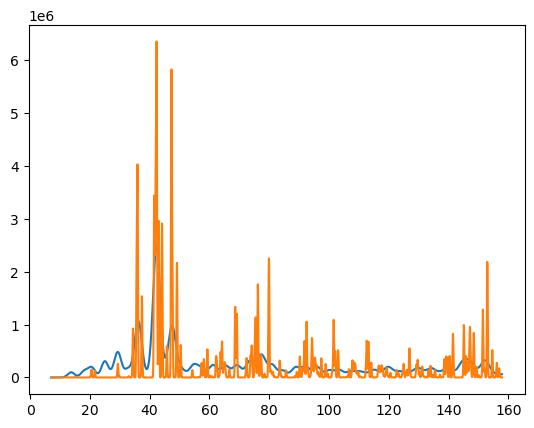

Step 3201: Lengths - tensor([[5.2382, 6.7231, 6.7385]], device='cuda:0', requires_grad=True), Angles - tensor([[78.8857, 75.5230, 74.8177]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[ 0.0704,  0.3063,  0.1438],
        [ 0.4622,  0.9423,  0.2748],
        [ 0.0256,  0.5739,  0.4094],
        [ 0.5092,  0.8379,  0.6601],
        [ 0.5564,  0.5261,  0.4555],
        [ 0.3666,  0.2087,  0.5341],
        [ 0.1052,  0.6691,  1.0119],
        [ 0.9341, -0.0491,  0.3026],
        [ 0.7505,  0.5181,  0.8440],
        [ 0.5566,  0.3023,  0.1612],
        [ 0.0417,  0.8339,  0.6454],
        [ 0.0043,  0.0750,  0.9193],
        [ 0.5370,  0.1606,  0.8422]], device='cuda:0', requires_grad=True), Loss - -0.6649134159088135


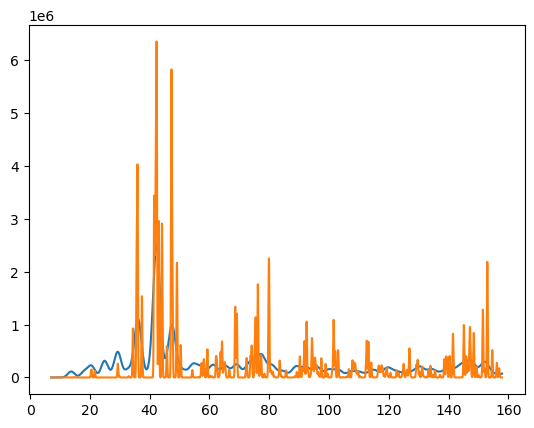

Step 3401: Lengths - tensor([[5.2652, 6.7222, 6.7337]], device='cuda:0', requires_grad=True), Angles - tensor([[78.8394, 75.5453, 74.8192]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[ 7.4964e-02,  3.0174e-01,  1.4621e-01],
        [ 4.6838e-01,  9.4413e-01,  2.7594e-01],
        [ 2.6748e-02,  5.7058e-01,  4.0966e-01],
        [ 5.0796e-01,  8.3636e-01,  6.6178e-01],
        [ 5.6472e-01,  5.3221e-01,  4.4314e-01],
        [ 3.6779e-01,  2.1321e-01,  5.3563e-01],
        [ 8.1458e-02,  6.7138e-01,  1.0190e+00],
        [ 9.2990e-01, -4.6900e-02,  3.0334e-01],
        [ 7.6202e-01,  5.1585e-01,  8.4246e-01],
        [ 5.5332e-01,  3.0227e-01,  1.5922e-01],
        [ 4.4387e-02,  8.3231e-01,  6.4621e-01],
        [-6.5151e-04,  7.5407e-02,  9.1957e-01],
        [ 5.3888e-01,  1.5661e-01,  8.4222e-01]], device='cuda:0',
       requires_grad=True), Loss - -0.6669402122497559


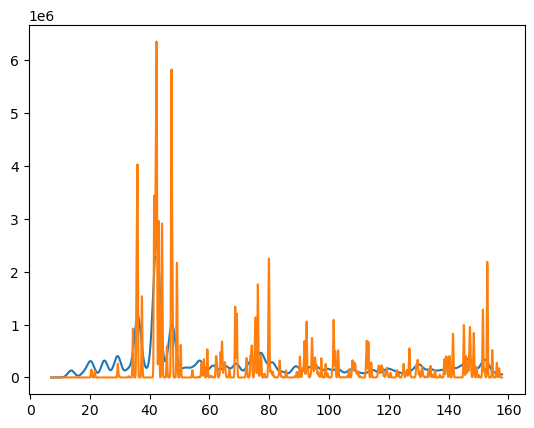

Step 3601: Lengths - tensor([[5.2806, 6.7200, 6.7390]], device='cuda:0', requires_grad=True), Angles - tensor([[78.7944, 75.5644, 74.8380]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[ 0.0604,  0.3082,  0.1367],
        [ 0.4838,  0.9442,  0.2721],
        [ 0.0254,  0.5654,  0.4021],
        [ 0.5041,  0.8291,  0.6691],
        [ 0.5694,  0.5339,  0.4345],
        [ 0.3723,  0.2174,  0.5475],
        [ 0.0111,  0.7068,  1.0429],
        [ 0.9375, -0.0372,  0.3034],
        [ 0.8248,  0.4960,  0.8280],
        [ 0.5204,  0.3182,  0.1592],
        [ 0.0491,  0.8175,  0.6433],
        [ 0.0105,  0.0696,  0.9106],
        [ 0.5511,  0.1360,  0.8549]], device='cuda:0', requires_grad=True), Loss - -0.6707502007484436


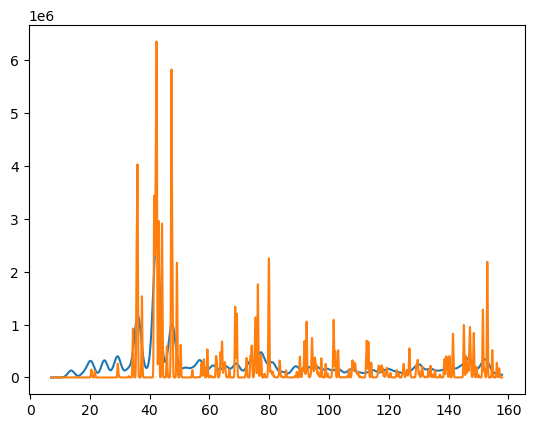

Step 3801: Lengths - tensor([[5.2796, 6.7223, 6.7394]], device='cuda:0', requires_grad=True), Angles - tensor([[78.7596, 75.5827, 74.8580]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[ 0.0539,  0.3119,  0.1368],
        [ 0.4834,  0.9463,  0.2706],
        [ 0.0271,  0.5647,  0.4012],
        [ 0.5079,  0.8263,  0.6676],
        [ 0.5688,  0.5321,  0.4387],
        [ 0.3761,  0.2154,  0.5469],
        [ 0.0079,  0.7089,  1.0435],
        [ 0.9372, -0.0347,  0.3031],
        [ 0.8301,  0.4934,  0.8268],
        [ 0.5084,  0.3249,  0.1622],
        [ 0.0534,  0.8150,  0.6410],
        [ 0.0122,  0.0699,  0.9091],
        [ 0.5533,  0.1311,  0.8567]], device='cuda:0', requires_grad=True), Loss - -0.6724064350128174


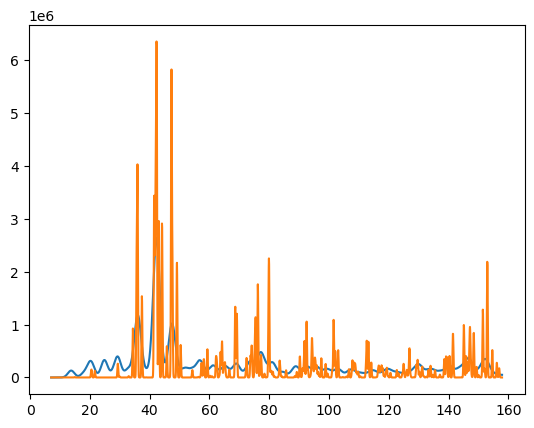

Step 4001: Lengths - tensor([[5.2791, 6.7232, 6.7393]], device='cuda:0', requires_grad=True), Angles - tensor([[78.7302, 75.5997, 74.8756]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[ 0.0525,  0.3125,  0.1368],
        [ 0.4826,  0.9472,  0.2700],
        [ 0.0285,  0.5638,  0.4014],
        [ 0.5089,  0.8257,  0.6677],
        [ 0.5689,  0.5314,  0.4401],
        [ 0.3768,  0.2148,  0.5458],
        [ 0.0078,  0.7085,  1.0443],
        [ 0.9366, -0.0343,  0.3037],
        [ 0.8313,  0.4929,  0.8261],
        [ 0.5070,  0.3257,  0.1626],
        [ 0.0538,  0.8145,  0.6414],
        [ 0.0122,  0.0700,  0.9093],
        [ 0.5529,  0.1327,  0.8553]], device='cuda:0', requires_grad=True), Loss - -0.6739451885223389


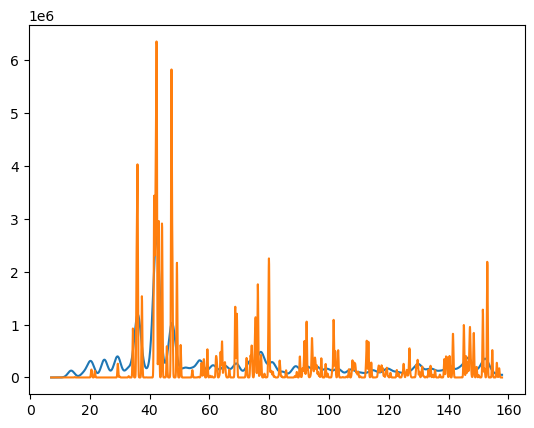

Step 4201: Lengths - tensor([[5.2789, 6.7239, 6.7390]], device='cuda:0', requires_grad=True), Angles - tensor([[78.7037, 75.6165, 74.8917]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[ 0.0527,  0.3122,  0.1366],
        [ 0.4820,  0.9476,  0.2694],
        [ 0.0296,  0.5629,  0.4019],
        [ 0.5087,  0.8257,  0.6682],
        [ 0.5690,  0.5312,  0.4407],
        [ 0.3767,  0.2146,  0.5446],
        [ 0.0080,  0.7077,  1.0451],
        [ 0.9360, -0.0344,  0.3044],
        [ 0.8315,  0.4929,  0.8258],
        [ 0.5082,  0.3252,  0.1624],
        [ 0.0532,  0.8144,  0.6422],
        [ 0.0123,  0.0699,  0.9096],
        [ 0.5520,  0.1353,  0.8535]], device='cuda:0', requires_grad=True), Loss - -0.6754447817802429


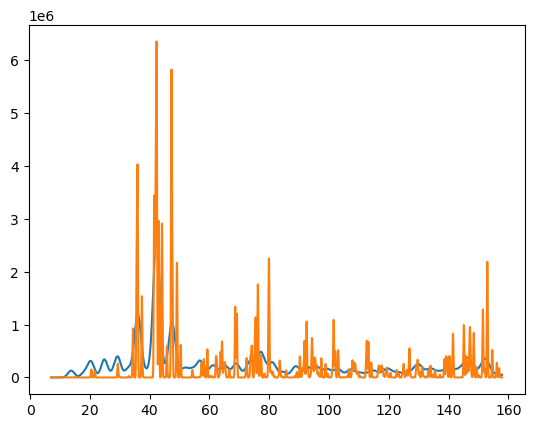

Step 4401: Lengths - tensor([[5.2788, 6.7246, 6.7389]], device='cuda:0', requires_grad=True), Angles - tensor([[78.6798, 75.6330, 74.9067]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[ 0.0531,  0.3119,  0.1363],
        [ 0.4817,  0.9480,  0.2689],
        [ 0.0305,  0.5620,  0.4023],
        [ 0.5084,  0.8258,  0.6687],
        [ 0.5690,  0.5312,  0.4411],
        [ 0.3766,  0.2145,  0.5437],
        [ 0.0082,  0.7071,  1.0458],
        [ 0.9355, -0.0346,  0.3050],
        [ 0.8313,  0.4930,  0.8255],
        [ 0.5093,  0.3247,  0.1621],
        [ 0.0526,  0.8143,  0.6429],
        [ 0.0124,  0.0698,  0.9099],
        [ 0.5512,  0.1374,  0.8521]], device='cuda:0', requires_grad=True), Loss - -0.676913321018219


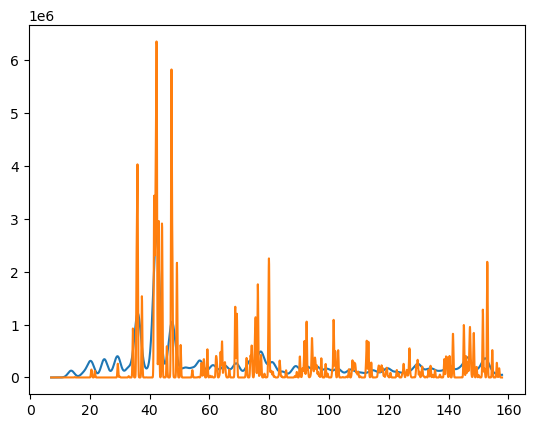

Step 4601: Lengths - tensor([[5.2788, 6.7253, 6.7390]], device='cuda:0', requires_grad=True), Angles - tensor([[78.6577, 75.6483, 74.9204]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[ 0.0534,  0.3116,  0.1361],
        [ 0.4816,  0.9482,  0.2685],
        [ 0.0311,  0.5613,  0.4026],
        [ 0.5083,  0.8259,  0.6690],
        [ 0.5690,  0.5312,  0.4416],
        [ 0.3766,  0.2145,  0.5429],
        [ 0.0084,  0.7066,  1.0463],
        [ 0.9351, -0.0347,  0.3055],
        [ 0.8310,  0.4931,  0.8254],
        [ 0.5103,  0.3243,  0.1619],
        [ 0.0523,  0.8143,  0.6434],
        [ 0.0124,  0.0698,  0.9100],
        [ 0.5505,  0.1390,  0.8511]], device='cuda:0', requires_grad=True), Loss - -0.678353488445282


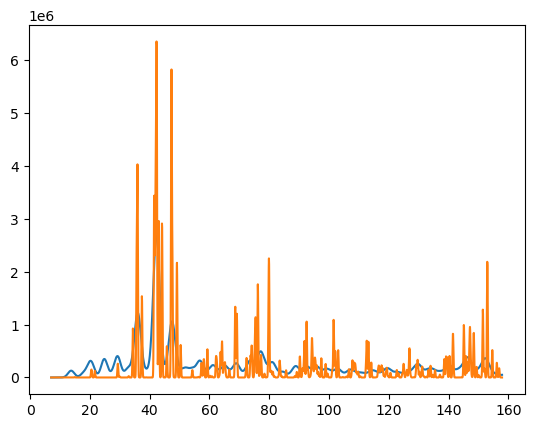

Step 4801: Lengths - tensor([[5.2788, 6.7259, 6.7392]], device='cuda:0', requires_grad=True), Angles - tensor([[78.6373, 75.6636, 74.9332]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[ 0.0537,  0.3114,  0.1359],
        [ 0.4816,  0.9484,  0.2680],
        [ 0.0316,  0.5607,  0.4030],
        [ 0.5082,  0.8259,  0.6692],
        [ 0.5689,  0.5312,  0.4419],
        [ 0.3766,  0.2144,  0.5422],
        [ 0.0086,  0.7061,  1.0468],
        [ 0.9348, -0.0347,  0.3060],
        [ 0.8306,  0.4934,  0.8253],
        [ 0.5111,  0.3240,  0.1617],
        [ 0.0520,  0.8143,  0.6438],
        [ 0.0123,  0.0698,  0.9102],
        [ 0.5499,  0.1403,  0.8504]], device='cuda:0', requires_grad=True), Loss - -0.679771363735199


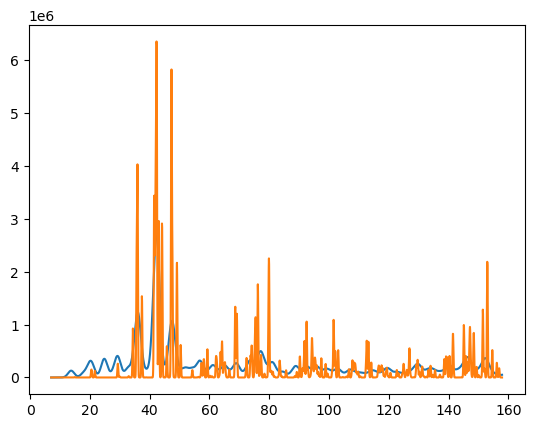

Step 5001: Lengths - tensor([[5.2788, 6.7265, 6.7396]], device='cuda:0', requires_grad=True), Angles - tensor([[78.6179, 75.6784, 74.9454]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[ 0.0539,  0.3112,  0.1357],
        [ 0.4818,  0.9486,  0.2677],
        [ 0.0319,  0.5601,  0.4032],
        [ 0.5082,  0.8259,  0.6694],
        [ 0.5689,  0.5313,  0.4422],
        [ 0.3766,  0.2144,  0.5416],
        [ 0.0089,  0.7056,  1.0471],
        [ 0.9345, -0.0348,  0.3064],
        [ 0.8299,  0.4937,  0.8252],
        [ 0.5117,  0.3237,  0.1615],
        [ 0.0518,  0.8143,  0.6442],
        [ 0.0123,  0.0699,  0.9104],
        [ 0.5494,  0.1414,  0.8498]], device='cuda:0', requires_grad=True), Loss - -0.6811693906784058


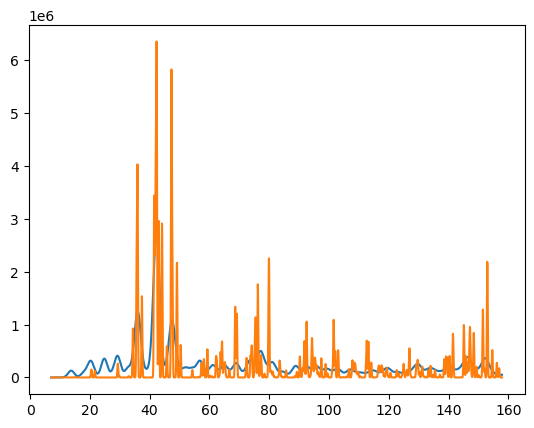

Step 5201: Lengths - tensor([[5.2789, 6.7271, 6.7400]], device='cuda:0', requires_grad=True), Angles - tensor([[78.5996, 75.6922, 74.9566]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[ 0.0542,  0.3109,  0.1355],
        [ 0.4820,  0.9486,  0.2675],
        [ 0.0321,  0.5597,  0.4035],
        [ 0.5083,  0.8259,  0.6695],
        [ 0.5689,  0.5313,  0.4424],
        [ 0.3766,  0.2143,  0.5410],
        [ 0.0093,  0.7050,  1.0474],
        [ 0.9343, -0.0348,  0.3067],
        [ 0.8291,  0.4940,  0.8251],
        [ 0.5124,  0.3235,  0.1612],
        [ 0.0516,  0.8143,  0.6446],
        [ 0.0122,  0.0700,  0.9105],
        [ 0.5488,  0.1424,  0.8493]], device='cuda:0', requires_grad=True), Loss - -0.682548463344574


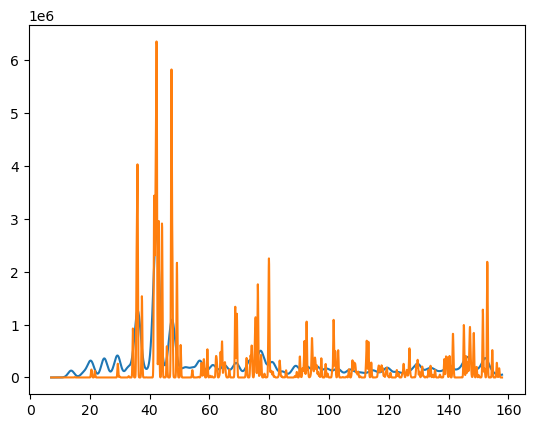

Step 5401: Lengths - tensor([[5.2791, 6.7277, 6.7404]], device='cuda:0', requires_grad=True), Angles - tensor([[78.5821, 75.7059, 74.9673]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[ 0.0545,  0.3106,  0.1353],
        [ 0.4824,  0.9487,  0.2673],
        [ 0.0321,  0.5593,  0.4038],
        [ 0.5084,  0.8259,  0.6696],
        [ 0.5689,  0.5314,  0.4425],
        [ 0.3766,  0.2144,  0.5405],
        [ 0.0098,  0.7045,  1.0477],
        [ 0.9341, -0.0349,  0.3071],
        [ 0.8282,  0.4944,  0.8251],
        [ 0.5131,  0.3232,  0.1609],
        [ 0.0514,  0.8143,  0.6451],
        [ 0.0121,  0.0701,  0.9106],
        [ 0.5483,  0.1433,  0.8489]], device='cuda:0', requires_grad=True), Loss - -0.6839121580123901


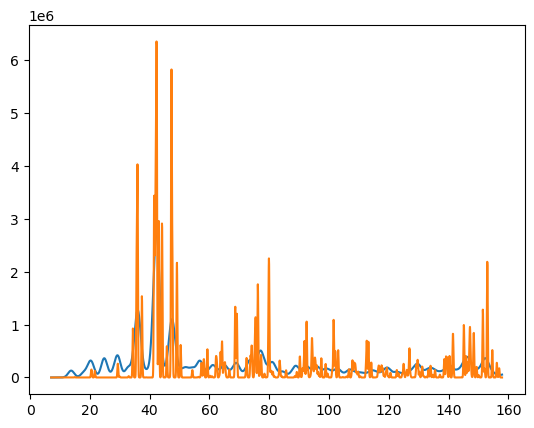

Step 5601: Lengths - tensor([[5.2793, 6.7283, 6.7408]], device='cuda:0', requires_grad=True), Angles - tensor([[78.5653, 75.7185, 74.9774]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[ 0.0549,  0.3103,  0.1351],
        [ 0.4828,  0.9486,  0.2673],
        [ 0.0319,  0.5590,  0.4041],
        [ 0.5085,  0.8260,  0.6696],
        [ 0.5689,  0.5314,  0.4426],
        [ 0.3766,  0.2144,  0.5400],
        [ 0.0104,  0.7038,  1.0479],
        [ 0.9339, -0.0349,  0.3074],
        [ 0.8270,  0.4949,  0.8250],
        [ 0.5138,  0.3229,  0.1606],
        [ 0.0513,  0.8144,  0.6455],
        [ 0.0119,  0.0702,  0.9107],
        [ 0.5479,  0.1442,  0.8486]], device='cuda:0', requires_grad=True), Loss - -0.6852604150772095


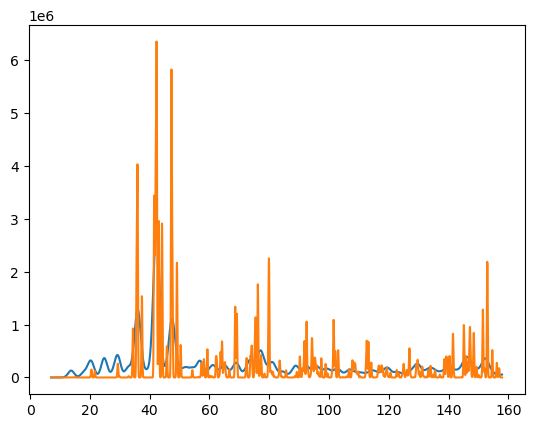

Step 5801: Lengths - tensor([[5.2796, 6.7290, 6.7413]], device='cuda:0', requires_grad=True), Angles - tensor([[78.5485, 75.7307, 74.9865]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[ 0.0553,  0.3098,  0.1350],
        [ 0.4834,  0.9486,  0.2673],
        [ 0.0315,  0.5589,  0.4044],
        [ 0.5086,  0.8260,  0.6696],
        [ 0.5689,  0.5315,  0.4426],
        [ 0.3766,  0.2145,  0.5395],
        [ 0.0112,  0.7031,  1.0481],
        [ 0.9338, -0.0350,  0.3077],
        [ 0.8256,  0.4954,  0.8248],
        [ 0.5146,  0.3226,  0.1602],
        [ 0.0512,  0.8145,  0.6461],
        [ 0.0117,  0.0703,  0.9107],
        [ 0.5474,  0.1449,  0.8483]], device='cuda:0', requires_grad=True), Loss - -0.6865960955619812


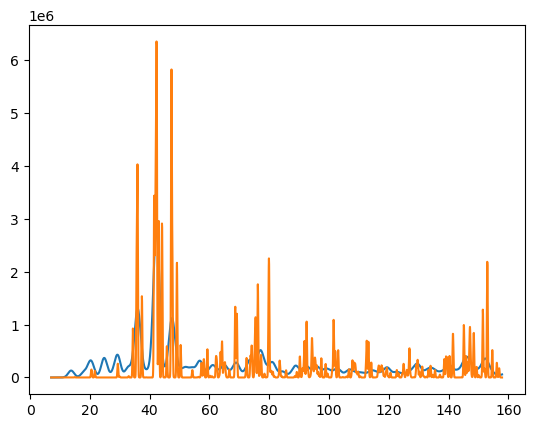

Step 6001: Lengths - tensor([[5.2801, 6.7297, 6.7417]], device='cuda:0', requires_grad=True), Angles - tensor([[78.5324, 75.7417, 74.9957]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[ 0.0559,  0.3093,  0.1349],
        [ 0.4841,  0.9484,  0.2675],
        [ 0.0308,  0.5590,  0.4048],
        [ 0.5088,  0.8262,  0.6695],
        [ 0.5689,  0.5316,  0.4426],
        [ 0.3765,  0.2147,  0.5390],
        [ 0.0122,  0.7023,  1.0483],
        [ 0.9337, -0.0350,  0.3080],
        [ 0.8239,  0.4960,  0.8246],
        [ 0.5156,  0.3221,  0.1598],
        [ 0.0510,  0.8145,  0.6467],
        [ 0.0115,  0.0705,  0.9107],
        [ 0.5470,  0.1455,  0.8480]], device='cuda:0', requires_grad=True), Loss - -0.6879193782806396


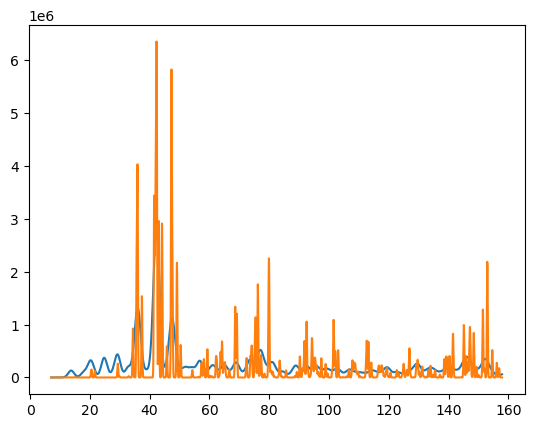

Step 6201: Lengths - tensor([[5.2807, 6.7304, 6.7421]], device='cuda:0', requires_grad=True), Angles - tensor([[78.5172, 75.7521, 75.0035]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[ 0.0566,  0.3086,  0.1348],
        [ 0.4850,  0.9481,  0.2679],
        [ 0.0296,  0.5594,  0.4052],
        [ 0.5089,  0.8264,  0.6694],
        [ 0.5689,  0.5317,  0.4425],
        [ 0.3765,  0.2150,  0.5385],
        [ 0.0134,  0.7013,  1.0484],
        [ 0.9337, -0.0351,  0.3083],
        [ 0.8218,  0.4967,  0.8243],
        [ 0.5167,  0.3216,  0.1593],
        [ 0.0509,  0.8147,  0.6474],
        [ 0.0113,  0.0707,  0.9106],
        [ 0.5466,  0.1461,  0.8478]], device='cuda:0', requires_grad=True), Loss - -0.689230740070343


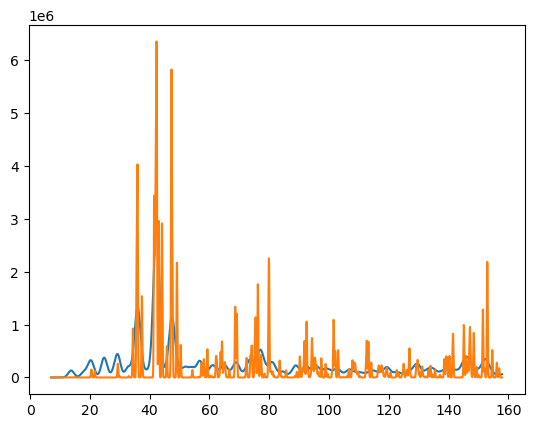

Step 6401: Lengths - tensor([[5.2816, 6.7313, 6.7425]], device='cuda:0', requires_grad=True), Angles - tensor([[78.5019, 75.7613, 75.0111]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[ 0.0576,  0.3076,  0.1348],
        [ 0.4860,  0.9477,  0.2684],
        [ 0.0281,  0.5600,  0.4057],
        [ 0.5090,  0.8268,  0.6694],
        [ 0.5688,  0.5319,  0.4424],
        [ 0.3763,  0.2154,  0.5380],
        [ 0.0149,  0.7002,  1.0485],
        [ 0.9338, -0.0351,  0.3085],
        [ 0.8193,  0.4976,  0.8238],
        [ 0.5182,  0.3208,  0.1586],
        [ 0.0507,  0.8148,  0.6482],
        [ 0.0110,  0.0710,  0.9103],
        [ 0.5462,  0.1465,  0.8477]], device='cuda:0', requires_grad=True), Loss - -0.6905338168144226


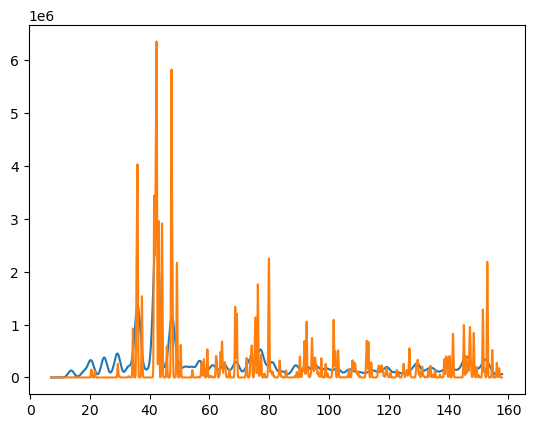

Step 6601: Lengths - tensor([[5.2826, 6.7322, 6.7427]], device='cuda:0', requires_grad=True), Angles - tensor([[78.4867, 75.7694, 75.0187]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[ 0.0589,  0.3063,  0.1348],
        [ 0.4872,  0.9473,  0.2692],
        [ 0.0262,  0.5610,  0.4063],
        [ 0.5090,  0.8273,  0.6693],
        [ 0.5687,  0.5320,  0.4423],
        [ 0.3761,  0.2159,  0.5375],
        [ 0.0168,  0.6987,  1.0486],
        [ 0.9340, -0.0351,  0.3088],
        [ 0.8163,  0.4986,  0.8230],
        [ 0.5199,  0.3199,  0.1579],
        [ 0.0504,  0.8150,  0.6492],
        [ 0.0105,  0.0713,  0.9100],
        [ 0.5458,  0.1468,  0.8476]], device='cuda:0', requires_grad=True), Loss - -0.691831111907959


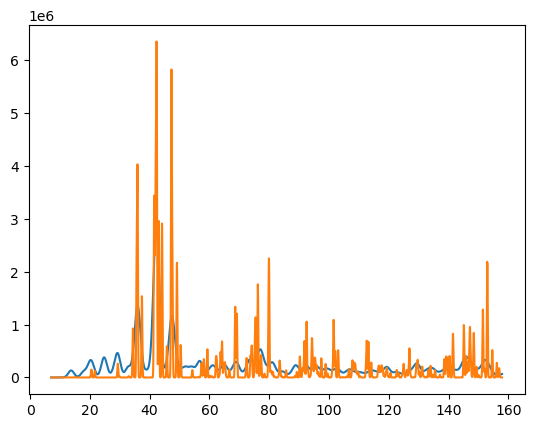

Step 6801: Lengths - tensor([[5.2839, 6.7332, 6.7430]], device='cuda:0', requires_grad=True), Angles - tensor([[78.4703, 75.7769, 75.0262]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[ 0.0605,  0.3049,  0.1349],
        [ 0.4884,  0.9468,  0.2702],
        [ 0.0242,  0.5622,  0.4070],
        [ 0.5089,  0.8280,  0.6692],
        [ 0.5687,  0.5320,  0.4421],
        [ 0.3758,  0.2166,  0.5370],
        [ 0.0190,  0.6971,  1.0487],
        [ 0.9341, -0.0351,  0.3090],
        [ 0.8130,  0.4998,  0.8218],
        [ 0.5220,  0.3188,  0.1570],
        [ 0.0502,  0.8151,  0.6503],
        [ 0.0099,  0.0718,  0.9096],
        [ 0.5452,  0.1471,  0.8475]], device='cuda:0', requires_grad=True), Loss - -0.6931259632110596


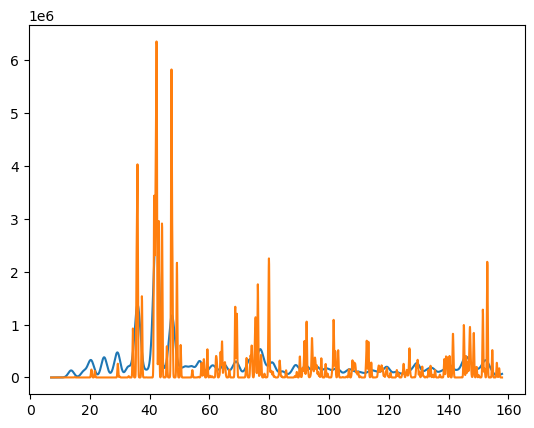

Step 7001: Lengths - tensor([[5.2851, 6.7342, 6.7432]], device='cuda:0', requires_grad=True), Angles - tensor([[78.4536, 75.7830, 75.0323]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[ 0.0622,  0.3033,  0.1350],
        [ 0.4894,  0.9464,  0.2713],
        [ 0.0224,  0.5634,  0.4077],
        [ 0.5086,  0.8287,  0.6692],
        [ 0.5689,  0.5319,  0.4419],
        [ 0.3754,  0.2174,  0.5365],
        [ 0.0215,  0.6954,  1.0488],
        [ 0.9343, -0.0350,  0.3094],
        [ 0.8096,  0.5011,  0.8202],
        [ 0.5240,  0.3177,  0.1561],
        [ 0.0499,  0.8152,  0.6516],
        [ 0.0091,  0.0724,  0.9093],
        [ 0.5446,  0.1473,  0.8475]], device='cuda:0', requires_grad=True), Loss - -0.6944166421890259


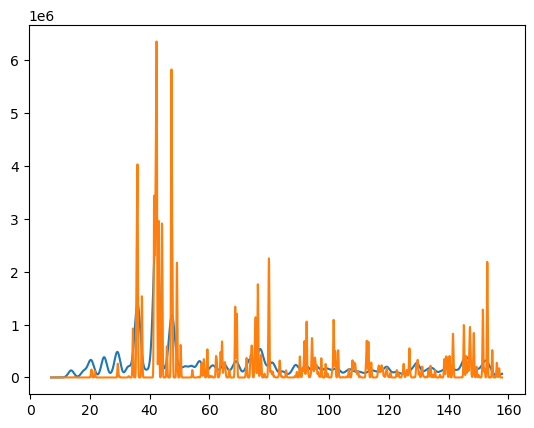

Step 7201: Lengths - tensor([[5.2862, 6.7351, 6.7435]], device='cuda:0', requires_grad=True), Angles - tensor([[78.4380, 75.7880, 75.0379]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[ 0.0637,  0.3020,  0.1351],
        [ 0.4903,  0.9461,  0.2724],
        [ 0.0211,  0.5644,  0.4083],
        [ 0.5083,  0.8293,  0.6693],
        [ 0.5693,  0.5316,  0.4417],
        [ 0.3751,  0.2179,  0.5360],
        [ 0.0238,  0.6939,  1.0488],
        [ 0.9343, -0.0347,  0.3099],
        [ 0.8065,  0.5021,  0.8182],
        [ 0.5258,  0.3169,  0.1553],
        [ 0.0496,  0.8152,  0.6527],
        [ 0.0082,  0.0731,  0.9091],
        [ 0.5439,  0.1475,  0.8475]], device='cuda:0', requires_grad=True), Loss - -0.6956998705863953


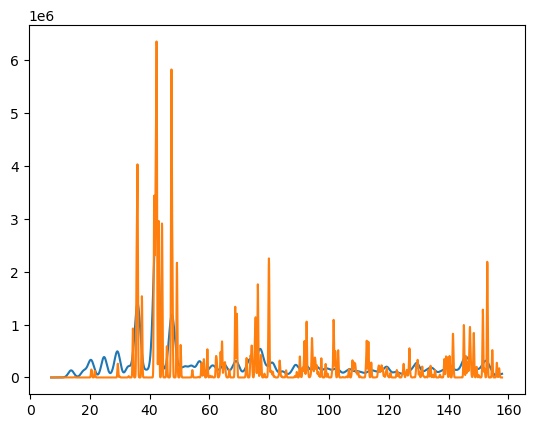

Step 7401: Lengths - tensor([[5.2871, 6.7358, 6.7439]], device='cuda:0', requires_grad=True), Angles - tensor([[78.4228, 75.7920, 75.0419]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[ 0.0650,  0.3011,  0.1352],
        [ 0.4909,  0.9459,  0.2735],
        [ 0.0204,  0.5650,  0.4087],
        [ 0.5080,  0.8298,  0.6695],
        [ 0.5698,  0.5310,  0.4417],
        [ 0.3750,  0.2181,  0.5355],
        [ 0.0258,  0.6927,  1.0489],
        [ 0.9342, -0.0343,  0.3105],
        [ 0.8039,  0.5029,  0.8159],
        [ 0.5273,  0.3163,  0.1546],
        [ 0.0494,  0.8150,  0.6538],
        [ 0.0071,  0.0738,  0.9091],
        [ 0.5431,  0.1479,  0.8475]], device='cuda:0', requires_grad=True), Loss - -0.696975827217102


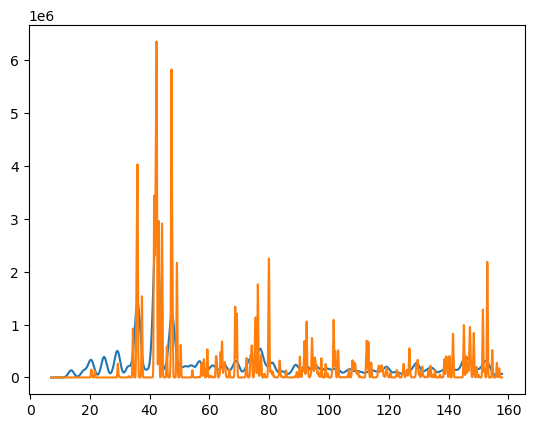

Step 7601: Lengths - tensor([[5.2879, 6.7364, 6.7444]], device='cuda:0', requires_grad=True), Angles - tensor([[78.4086, 75.7949, 75.0444]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[ 0.0660,  0.3005,  0.1353],
        [ 0.4915,  0.9457,  0.2744],
        [ 0.0201,  0.5653,  0.4090],
        [ 0.5077,  0.8302,  0.6696],
        [ 0.5703,  0.5303,  0.4418],
        [ 0.3751,  0.2182,  0.5350],
        [ 0.0277,  0.6918,  1.0489],
        [ 0.9340, -0.0337,  0.3113],
        [ 0.8016,  0.5033,  0.8135],
        [ 0.5284,  0.3160,  0.1540],
        [ 0.0492,  0.8147,  0.6547],
        [ 0.0060,  0.0745,  0.9092],
        [ 0.5423,  0.1484,  0.8475]], device='cuda:0', requires_grad=True), Loss - -0.6982435584068298


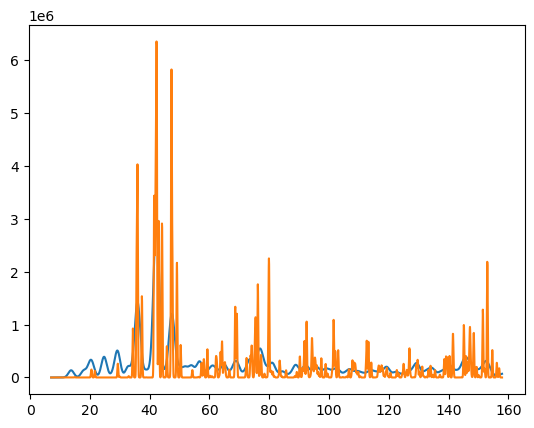

Step 7801: Lengths - tensor([[5.2885, 6.7369, 6.7449]], device='cuda:0', requires_grad=True), Angles - tensor([[78.3952, 75.7964, 75.0451]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[ 0.0668,  0.3001,  0.1355],
        [ 0.4920,  0.9455,  0.2751],
        [ 0.0201,  0.5655,  0.4091],
        [ 0.5074,  0.8304,  0.6698],
        [ 0.5709,  0.5295,  0.4421],
        [ 0.3753,  0.2180,  0.5344],
        [ 0.0294,  0.6911,  1.0490],
        [ 0.9338, -0.0331,  0.3121],
        [ 0.7995,  0.5036,  0.8111],
        [ 0.5293,  0.3159,  0.1536],
        [ 0.0490,  0.8143,  0.6556],
        [ 0.0049,  0.0753,  0.9095],
        [ 0.5415,  0.1490,  0.8475]], device='cuda:0', requires_grad=True), Loss - -0.6995036602020264


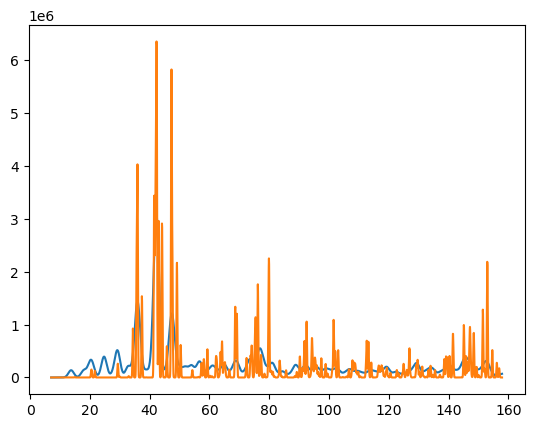

Step 8001: Lengths - tensor([[5.2891, 6.7374, 6.7454]], device='cuda:0', requires_grad=True), Angles - tensor([[78.3830, 75.7967, 75.0445]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[ 0.0675,  0.2998,  0.1357],
        [ 0.4924,  0.9454,  0.2757],
        [ 0.0203,  0.5656,  0.4092],
        [ 0.5072,  0.8306,  0.6700],
        [ 0.5715,  0.5286,  0.4425],
        [ 0.3756,  0.2178,  0.5338],
        [ 0.0310,  0.6905,  1.0490],
        [ 0.9336, -0.0325,  0.3129],
        [ 0.7975,  0.5038,  0.8088],
        [ 0.5300,  0.3160,  0.1533],
        [ 0.0489,  0.8139,  0.6563],
        [ 0.0037,  0.0760,  0.9098],
        [ 0.5407,  0.1496,  0.8475]], device='cuda:0', requires_grad=True), Loss - -0.7007567882537842


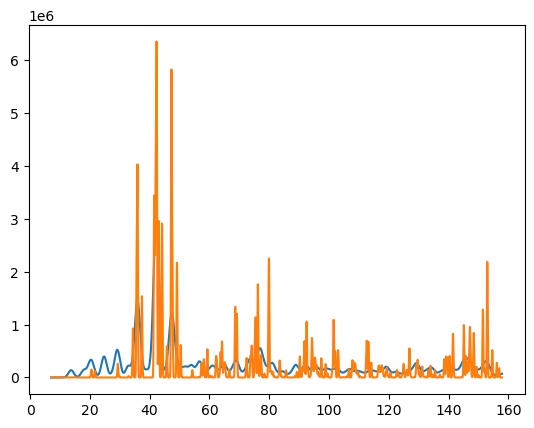

Step 8201: Lengths - tensor([[5.2896, 6.7379, 6.7458]], device='cuda:0', requires_grad=True), Angles - tensor([[78.3718, 75.7961, 75.0428]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[ 0.0682,  0.2996,  0.1359],
        [ 0.4929,  0.9452,  0.2760],
        [ 0.0207,  0.5656,  0.4092],
        [ 0.5071,  0.8308,  0.6702],
        [ 0.5720,  0.5278,  0.4430],
        [ 0.3759,  0.2174,  0.5333],
        [ 0.0324,  0.6901,  1.0491],
        [ 0.9334, -0.0319,  0.3136],
        [ 0.7956,  0.5038,  0.8066],
        [ 0.5307,  0.3161,  0.1531],
        [ 0.0488,  0.8136,  0.6568],
        [ 0.0025,  0.0768,  0.9101],
        [ 0.5399,  0.1503,  0.8474]], device='cuda:0', requires_grad=True), Loss - -0.7020034790039062


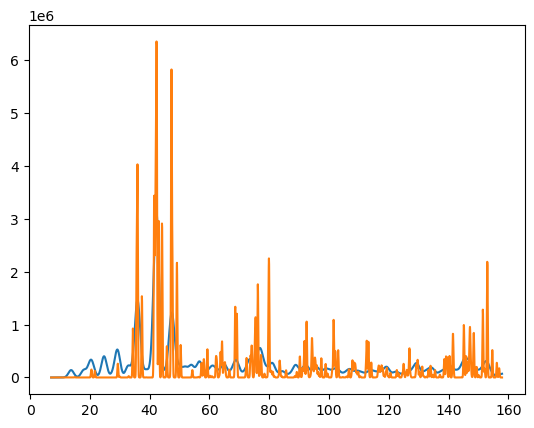

Step 8401: Lengths - tensor([[5.2901, 6.7383, 6.7462]], device='cuda:0', requires_grad=True), Angles - tensor([[78.3611, 75.7946, 75.0397]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[ 0.0689,  0.2995,  0.1361],
        [ 0.4933,  0.9450,  0.2762],
        [ 0.0211,  0.5655,  0.4093],
        [ 0.5070,  0.8309,  0.6704],
        [ 0.5724,  0.5270,  0.4436],
        [ 0.3762,  0.2171,  0.5327],
        [ 0.0335,  0.6898,  1.0492],
        [ 0.9332, -0.0314,  0.3141],
        [ 0.7938,  0.5038,  0.8048],
        [ 0.5311,  0.3163,  0.1530],
        [ 0.0487,  0.8133,  0.6573],
        [ 0.0015,  0.0774,  0.9103],
        [ 0.5393,  0.1509,  0.8474]], device='cuda:0', requires_grad=True), Loss - -0.7032439112663269


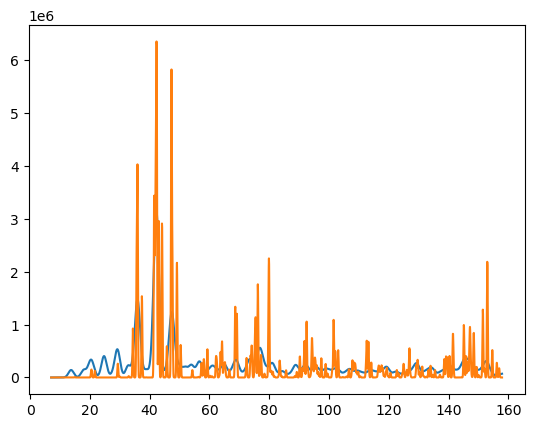

Step 8601: Lengths - tensor([[5.2905, 6.7387, 6.7466]], device='cuda:0', requires_grad=True), Angles - tensor([[78.3510, 75.7922, 75.0362]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[ 6.9418e-02,  2.9933e-01,  1.3627e-01],
        [ 4.9368e-01,  9.4487e-01,  2.7632e-01],
        [ 2.1460e-02,  5.6545e-01,  4.0931e-01],
        [ 5.0692e-01,  8.3101e-01,  6.7056e-01],
        [ 5.7274e-01,  5.2636e-01,  4.4410e-01],
        [ 3.7650e-01,  2.1670e-01,  5.3222e-01],
        [ 3.4354e-02,  6.8951e-01,  1.0493e+00],
        [ 9.3305e-01, -3.0962e-02,  3.1463e-01],
        [ 7.9229e-01,  5.0369e-01,  8.0336e-01],
        [ 5.3152e-01,  3.1646e-01,  1.5289e-01],
        [ 4.8621e-02,  8.1309e-01,  6.5759e-01],
        [ 6.2281e-04,  7.8041e-02,  9.1051e-01],
        [ 5.3871e-01,  1.5159e-01,  8.4731e-01]], device='cuda:0',
       requires_grad=True), Loss - -0.7044781446456909


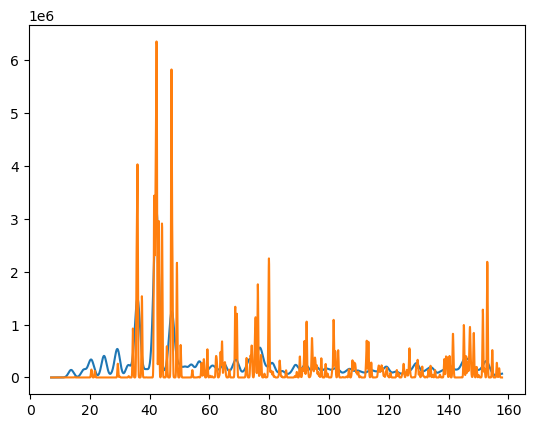

Step 8801: Lengths - tensor([[5.2909, 6.7391, 6.7471]], device='cuda:0', requires_grad=True), Angles - tensor([[78.3418, 75.7891, 75.0317]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[ 6.9840e-02,  2.9919e-01,  1.3639e-01],
        [ 4.9402e-01,  9.4471e-01,  2.7638e-01],
        [ 2.1816e-02,  5.6530e-01,  4.0932e-01],
        [ 5.0688e-01,  8.3106e-01,  6.7072e-01],
        [ 5.7290e-01,  5.2596e-01,  4.4457e-01],
        [ 3.7691e-01,  2.1633e-01,  5.3171e-01],
        [ 3.4988e-02,  6.8931e-01,  1.0493e+00],
        [ 9.3293e-01, -3.0701e-02,  3.1501e-01],
        [ 7.9111e-01,  5.0369e-01,  8.0235e-01],
        [ 5.3179e-01,  3.1656e-01,  1.5283e-01],
        [ 4.8539e-02,  8.1302e-01,  6.5785e-01],
        [-1.0127e-04,  7.8556e-02,  9.1065e-01],
        [ 5.3825e-01,  1.5216e-01,  8.4726e-01]], device='cuda:0',
       requires_grad=True), Loss - -0.7057052850723267


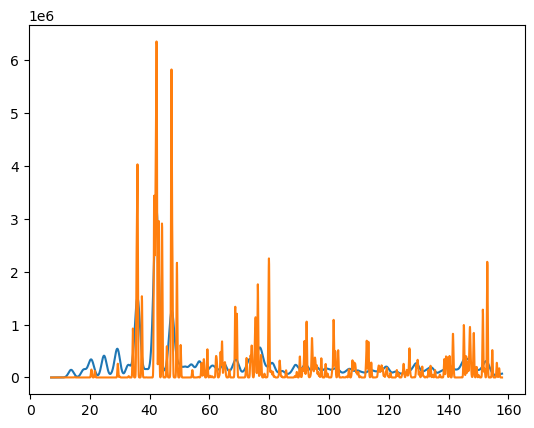

Step 9001: Lengths - tensor([[5.2912, 6.7394, 6.7476]], device='cuda:0', requires_grad=True), Angles - tensor([[78.3327, 75.7861, 75.0271]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[ 7.0118e-02,  2.9909e-01,  1.3644e-01],
        [ 4.9433e-01,  9.4455e-01,  2.7645e-01],
        [ 2.2114e-02,  5.6512e-01,  4.0930e-01],
        [ 5.0686e-01,  8.3107e-01,  6.7086e-01],
        [ 5.7297e-01,  5.2571e-01,  4.4496e-01],
        [ 3.7735e-01,  2.1597e-01,  5.3120e-01],
        [ 3.5473e-02,  6.8913e-01,  1.0493e+00],
        [ 9.3282e-01, -3.0523e-02,  3.1534e-01],
        [ 7.9026e-01,  5.0371e-01,  8.0164e-01],
        [ 5.3198e-01,  3.1662e-01,  1.5277e-01],
        [ 4.8461e-02,  8.1301e-01,  6.5805e-01],
        [-7.0504e-04,  7.9008e-02,  9.1076e-01],
        [ 5.3786e-01,  1.5268e-01,  8.4722e-01]], device='cuda:0',
       requires_grad=True), Loss - -0.7069258093833923


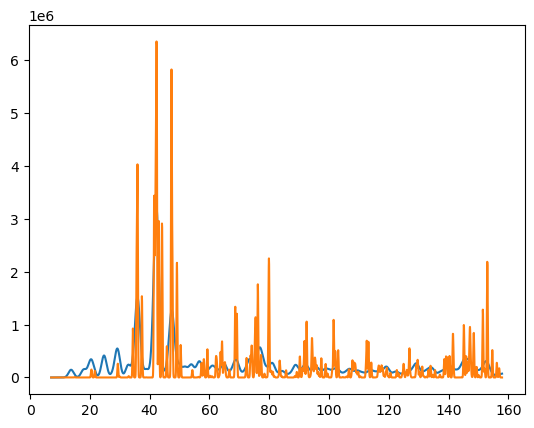

Step 9201: Lengths - tensor([[5.2915, 6.7397, 6.7482]], device='cuda:0', requires_grad=True), Angles - tensor([[78.3240, 75.7830, 75.0225]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[ 0.0703,  0.2990,  0.1365],
        [ 0.4946,  0.9444,  0.2765],
        [ 0.0224,  0.5649,  0.4092],
        [ 0.5068,  0.8310,  0.6710],
        [ 0.5729,  0.5256,  0.4453],
        [ 0.3778,  0.2156,  0.5307],
        [ 0.0359,  0.6890,  1.0493],
        [ 0.9327, -0.0304,  0.3156],
        [ 0.7897,  0.5038,  0.8012],
        [ 0.5321,  0.3166,  0.1527],
        [ 0.0484,  0.8131,  0.6582],
        [-0.0012,  0.0794,  0.9109],
        [ 0.5375,  0.1532,  0.8472]], device='cuda:0', requires_grad=True), Loss - -0.7081392407417297


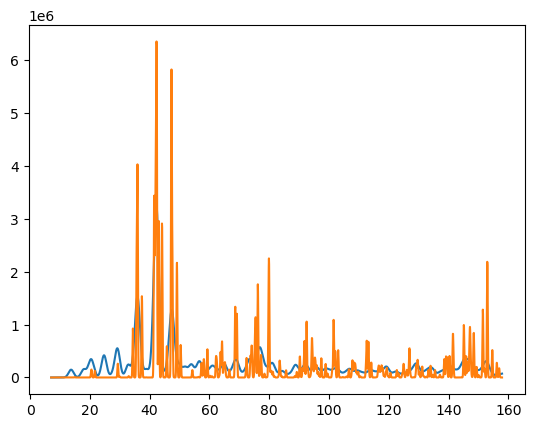

Step 9401: Lengths - tensor([[5.2919, 6.7399, 6.7489]], device='cuda:0', requires_grad=True), Angles - tensor([[78.3164, 75.7785, 75.0168]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[ 0.0703,  0.2990,  0.1364],
        [ 0.4949,  0.9442,  0.2766],
        [ 0.0226,  0.5646,  0.4091],
        [ 0.5068,  0.8310,  0.6711],
        [ 0.5727,  0.5257,  0.4456],
        [ 0.3784,  0.2153,  0.5302],
        [ 0.0361,  0.6888,  1.0492],
        [ 0.9327, -0.0304,  0.3159],
        [ 0.7894,  0.5039,  0.8010],
        [ 0.5322,  0.3166,  0.1527],
        [ 0.0483,  0.8132,  0.6584],
        [-0.0017,  0.0798,  0.9111],
        [ 0.5372,  0.1536,  0.8472]], device='cuda:0', requires_grad=True), Loss - -0.7093462347984314


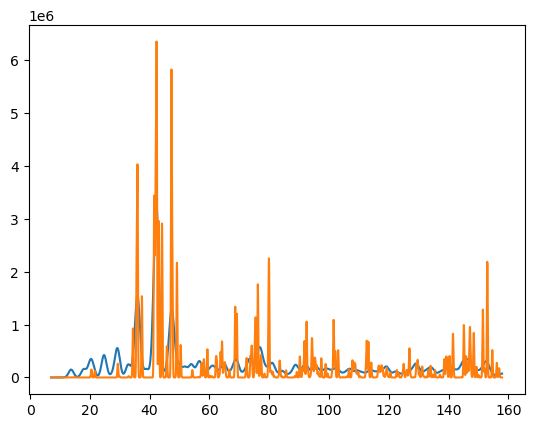

Step 9601: Lengths - tensor([[5.2922, 6.7401, 6.7497]], device='cuda:0', requires_grad=True), Angles - tensor([[78.3088, 75.7740, 75.0107]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[ 0.0702,  0.2989,  0.1364],
        [ 0.4951,  0.9440,  0.2767],
        [ 0.0229,  0.5642,  0.4088],
        [ 0.5068,  0.8309,  0.6712],
        [ 0.5723,  0.5260,  0.4460],
        [ 0.3791,  0.2149,  0.5296],
        [ 0.0363,  0.6886,  1.0491],
        [ 0.9326, -0.0306,  0.3161],
        [ 0.7893,  0.5041,  0.8009],
        [ 0.5322,  0.3165,  0.1526],
        [ 0.0481,  0.8135,  0.6585],
        [-0.0021,  0.0802,  0.9113],
        [ 0.5369,  0.1539,  0.8471]], device='cuda:0', requires_grad=True), Loss - -0.7105473875999451


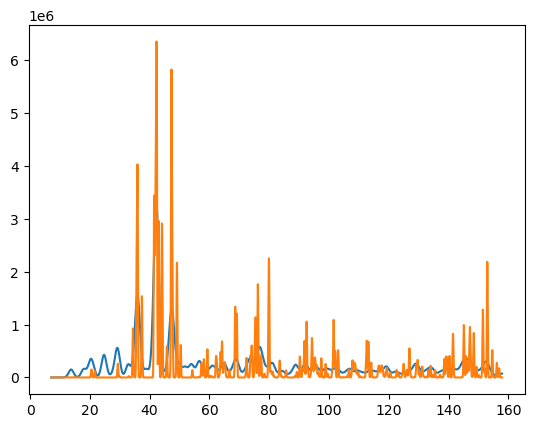

Step 9801: Lengths - tensor([[5.2925, 6.7402, 6.7506]], device='cuda:0', requires_grad=True), Angles - tensor([[78.3015, 75.7694, 75.0045]], device='cuda:0', requires_grad=True), Frac Coords - tensor([[ 0.0699,  0.2988,  0.1364],
        [ 0.4954,  0.9438,  0.2769],
        [ 0.0231,  0.5637,  0.4085],
        [ 0.5068,  0.8308,  0.6713],
        [ 0.5717,  0.5265,  0.4464],
        [ 0.3799,  0.2146,  0.5290],
        [ 0.0365,  0.6884,  1.0489],
        [ 0.9326, -0.0308,  0.3163],
        [ 0.7894,  0.5044,  0.8010],
        [ 0.5321,  0.3163,  0.1525],
        [ 0.0480,  0.8138,  0.6586],
        [-0.0024,  0.0805,  0.9116],
        [ 0.5367,  0.1542,  0.8471]], device='cuda:0', requires_grad=True), Loss - -0.7117422223091125
{'angles': tensor([[78.2955, 75.7648, 74.9985]], device='cuda:0', requires_grad=True), 'lengths': tensor([[5.2927, 6.7402, 6.7518]], device='cuda:0', requires_grad=True), 'frac_coords': tensor([[ 0.0696,  0.2988,  0.1364],
        [ 0.4956,  0.9436,  0.2770],


"\npattern[1][0][3].backward()\n#print(pattern[:,0,:])\n#print(batch['angles'][0])\nprint(batch['angles'].grad)\n#print(batch['frac_coords'][0])\nprint(batch['frac_coords'].grad)\n#scan = DC.bin_pattern_theta(pattern)\n#print(scan)\n#plt.plot(scan)"

In [140]:
print(DC.snap_structure(scan[0], batch_to_snap, iterations = 10000, learning_rate = 0.05, U = 0, V = 0, W = 10, sharpen_rate = 0.0001, plot_progress = True, plot_freq = 200))

"""
max_r = self.q_max / (2 * pi)
max_recip_length = q_max /2pi
two theta = 360 / pi * arcsin(wavelength * recip_length / 2)"""


"""
pattern[1][0][3].backward()
#print(pattern[:,0,:])
#print(batch['angles'][0])
print(batch['angles'].grad)
#print(batch['frac_coords'][0])
print(batch['frac_coords'].grad)
#scan = DC.bin_pattern_theta(pattern)
#print(scan)
#plt.plot(scan)"""

In [22]:
input_data_list = input_data_list + batch.to_data_list()

from torch_geometric.data import Batch

input_data_batch = Batch.from_data_list(input_data_list)

recon_out_name = "for_structure_snapping.pt"

model_path_as_str = '/home/gridsan/tmackey/hydra/singlerun/2024-01-11/augcag'

torch.save({
            'eval_setting': "not relevant here",
            'input_data_batch': input_data_batch,
            'frac_coords': frac_coords,
            'num_atoms': num_atoms,
            'atom_types': atom_types,
            'lengths': lengths,
            'angles': angles,
            'all_frac_coords_stack': all_frac_coords_stack,
            'all_atom_types_stack': all_atom_types_stack,
            'time': 0,
        }, model_path_as_str + recon_out_name)